In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('df_ready.csv')

In [ ]:
df.head(20)

,Architecture,Algorithm,Beta,Num_Flips,Flip_Below_11,Acc_At_Flip_Below_11,Final_Accuracy,Execution_Time_s,Success,Generations,Validation,Quantization,File,Class,Precision,Recall,F1-Score,Support
0,resnet20,AG,0.5,9,9.0,10.77,10.77,240.50,1.0,15.0,10000.0,8 bits,relatorio_final_resnet20_fbeta0.5.txt,Não Vulnerável (0),0.9989,0.9999,0.9994,12025.0
1,resnet20,AG,0.5,9,9.0,10.77,10.77,240.50,1.0,15.0,10000.0,8 bits,relatorio_final_resnet20_fbeta0.5.txt,Vulnerável (1),0.8333,0.2778,0.4167,18.0
2,resnet20,AG,2.3,9,9.0,11.23,11.23,1028.49,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta2.3.txt,Não Vulnerável (0),1.0000,0.9977,0.9988,12025.0
3,resnet20,AG,2.3,9,9.0,11.23,11.23,1028.49,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta2.3.txt,Vulnerável (1),0.3913,1.0000,0.5625,18.0
4,resnet20,AG,1.0,9,9.0,13.03,13.03,1046.39,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta1.0.txt,Não Vulnerável (0),0.9995,0.9991,0.9993,12025.0
5,resnet20,AG,1.0,9,9.0,13.03,13.03,1046.39,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta1.0.txt,Vulnerável (1),0.5217,0.6667,0.5854,18.0
6,resnet20,AG,3.0,9,9.0,16.26,16.26,1028.15,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta3.0.txt,Não Vulnerável (0),1.0000,0.9973,0.9987,12025.0
7,resnet20,AG,3.0,9,9.0,16.26,16.26,1028.15,0.0,70.0,10000.0,8 bits,relatorio_final_resnet20_fbeta3.0.txt,Vulnerável (1),0.3600,1.0000,0.5294,18.0
8,resnet20,GREEDY,2.3,15,9.0,10.43,10.00,838.10,1.0,NaN,10000.0,8 bits,relatorio_final_resnet20_fbeta2.3.txt,Não Vulnerável (0),1.0000,0.9977,0.9988,12025.0
9,resnet20,GREEDY,2.3,15,9.0,10.43,10.00,838.10,1.0,NaN,10000.0,8 bits,relatorio_final_resnet20_fbeta2.3.txt,Vulnerável (1),0.3913,1.0000,0.5625,18.0


In [ ]:
df[(df['Architecture'] == "resnet44") & (df['Acc_At_Flip_Below_11'] <  11) & (df['Flip_Below_11'] <=10)]

,Architecture,Algorithm,Beta,Num_Flips,Flip_Below_11,Acc_At_Flip_Below_11,Final_Accuracy,Execution_Time_s,Success,Generations,Validation,Quantization,File,Class,Precision,Recall,F1-Score,Support
481,resnet44,AG,2.3,10,10.0,10.87,10.87,647.86,NaN,33.0,NaN,8 bits,NaN,Vulnerável (1),0.6304,0.8529,NaN,NaN


In [1]:
pip install mrfi

In [2]:
import os
import csv
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import pandas as pd

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

# --- 2) Definição do Modelo ResNet-20 ---
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(64 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

def ResNet20(num_classes=10):
    return ResNet(BasicBlock, [3, 3, 3], num_classes=num_classes)

numero = 20
# --- Configurações ---
MODEL_PATH = "resnet20_cifar10.pth"
OUTPUT_CSV_PATH = f"resnet{numero}_module_nonbias_param_gradients.csv"
NUM_BATCHES_FOR_GRAD_AVG = 50
BATCH_SIZE = 128

# <<< MUDANÇA AQUI: A lista de módulos alvo foi atualizada para a ResNet-56 >>>
TARGET_MODULE_NAMES = {
    'conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2',
     'layer1.2.conv1', 'layer1.2.conv2', 'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.shortcut.0',
     'layer2.1.conv1', 'layer2.1.conv2', 'layer2.2.conv1', 'layer2.2.conv2', 'layer3.0.conv1',
     'layer3.0.conv2', 'layer3.0.shortcut.0', 'layer3.1.conv1', 'layer3.1.conv2', 'layer3.2.conv1', 'layer3.2.conv2', 'linear'
}
print(f"O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de {len(TARGET_MODULE_NAMES)} módulos.")

# --- 4) Carrega modelo e pesos ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {device}")
# <<< MUDANÇA AQUI: Instancia o modelo ResNet-56 >>>
model = ResNet20(num_classes=10).to(device)

# O restante do seu script para carregar os dados, calcular os gradientes,
# e salvar o CSV continuaria aqui...



O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de 22 módulos.

Usando dispositivo: cuda


In [3]:


import os
import csv
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import pandas as pd


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

# --- 2) Definição do Modelo ResNet (genérico) ---
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(64 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

def ResNet32(num_classes=10):
    # Para ResNet-32, o número de blocos é [5, 5, 5] (total 6*5 + 2 = 32 camadas)
    return ResNet(BasicBlock, [5, 5, 5], num_classes=num_classes)

numero = 32
# --- Configurações ---
MODEL_PATH = "resnet32_cifar10.pth"
OUTPUT_CSV_PATH = f"resnet{numero}_module_nonbias_param_gradients.csv"
NUM_BATCHES_FOR_GRAD_AVG = 50
BATCH_SIZE = 128

# <<< MUDANÇA AQUI: A lista de módulos alvo foi atualizada para a ResNet-56 >>>
TARGET_MODULE_NAMES = {
    'conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2', 'layer1.2.conv1',
     'layer1.2.conv2', 'layer1.3.conv1', 'layer1.3.conv2', 'layer1.4.conv1', 'layer1.4.conv2',
     'layer2.0.conv1', 'layer2.0.conv2','layer2.0.shortcut.0', 'layer2.1.conv1', 'layer2.1.conv2',
     'layer2.2.conv1', 'layer2.2.conv2', 'layer2.3.conv1', 'layer2.3.conv2','layer2.4.conv1',
     'layer2.4.conv2', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.shortcut.0',
     'layer3.1.conv1', 'layer3.1.conv2', 'layer3.2.conv1', 'layer3.2.conv2',
     'layer3.3.conv1', 'layer3.3.conv2', 'layer3.4.conv1', 'layer3.4.conv2', 'linear'
}
print(f"O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de {len(TARGET_MODULE_NAMES)} módulos.")

# --- 4) Carrega modelo e pesos ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {device}")
# <<< MUDANÇA AQUI: Instancia o modelo ResNet-56 >>>
model = ResNet32(num_classes=10).to(device)

# O restante do seu script para carregar os dados, calcular os gradientes,
# e salvar o CSV continuaria aqui...



O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de 34 módulos.

Usando dispositivo: cuda


In [4]:



import os
import csv
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import pandas as pd


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

# --- 2) Definição do Modelo ResNet (genérico) ---
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(64 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

# <<< MUDANÇA AQUI: Função fábrica para criar a ResNet-56 >>>
def ResNet56(num_classes=10):
    # Para ResNet-56, o número de blocos é [9, 9, 9] (total 6*9 + 2 = 56 camadas)
    return ResNet(BasicBlock, [9, 9, 9], num_classes=num_classes)

numero = 56
# --- Configurações ---
MODEL_PATH = "resnet56_cifar10.pth"
OUTPUT_CSV_PATH = f"resnet{numero}_module_nonbias_param_gradients.csv"
NUM_BATCHES_FOR_GRAD_AVG = 50
BATCH_SIZE = 128

# <<< MUDANÇA AQUI: A lista de módulos alvo foi atualizada para a ResNet-56 >>>
TARGET_MODULE_NAMES = {
    'conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2',
    'layer1.2.conv1', 'layer1.2.conv2', 'layer1.3.conv1', 'layer1.3.conv2',
    'layer1.4.conv1', 'layer1.4.conv2', 'layer1.5.conv1', 'layer1.5.conv2',
    'layer1.6.conv1', 'layer1.6.conv2', 'layer1.7.conv1', 'layer1.7.conv2',
    'layer1.8.conv1', 'layer1.8.conv2', 'layer2.0.conv1', 'layer2.0.conv2',
    'layer2.0.shortcut.0', 'layer2.1.conv1', 'layer2.1.conv2', 'layer2.2.conv1',
    'layer2.2.conv2', 'layer2.3.conv1', 'layer2.3.conv2', 'layer2.4.conv1',
    'layer2.4.conv2', 'layer2.5.conv1', 'layer2.5.conv2', 'layer2.6.conv1',
    'layer2.6.conv2', 'layer2.7.conv1', 'layer2.7.conv2', 'layer2.8.conv1',
    'layer2.8.conv2', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.shortcut.0',
    'layer3.1.conv1', 'layer3.1.conv2', 'layer3.2.conv1', 'layer3.2.conv2',
    'layer3.3.conv1', 'layer3.3.conv2', 'layer3.4.conv1', 'layer3.4.conv2',
    'layer3.5.conv1', 'layer3.5.conv2', 'layer3.6.conv1', 'layer3.6.conv2',
    'layer3.7.conv1', 'layer3.7.conv2', 'layer3.8.conv1', 'layer3.8.conv2', 'linear'
}
print(f"O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de {len(TARGET_MODULE_NAMES)} módulos.")

# --- 4) Carrega modelo e pesos ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {device}")
# <<< MUDANÇA AQUI: Instancia o modelo ResNet-56 >>>
model = ResNet56(num_classes=10).to(device)

# O restante do seu script para carregar os dados, calcular os gradientes,
# e salvar o CSV continuaria aqui...



O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de 58 módulos.

Usando dispositivo: cuda


In [5]:


import os
import csv
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import pandas as pd


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

# --- 2) Definição do Modelo ResNet (genérico) ---
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(64 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

# <<< MUDANÇA AQUI: Função fábrica para criar a ResNet-44 >>>
def ResNet44(num_classes=10):
    # Para ResNet-44, o número de blocos é [7, 7, 7] (total 6*7 + 2 = 44 camadas)
    return ResNet(BasicBlock, [7, 7, 7], num_classes=num_classes)

numero = 44
# --- Configurações ---
MODEL_PATH = "resnet44_cifar10.pth"
OUTPUT_CSV_PATH = f"resnet{numero}_module_nonbias_param_gradients.csv"
NUM_BATCHES_FOR_GRAD_AVG = 50
BATCH_SIZE = 128

# A lista de módulos alvo já está corretamente definida para a ResNet-32
TARGET_MODULE_NAMES = {
    'conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2', 'layer1.2.conv1', 'layer1.2.conv2',
    'layer1.3.conv1', 'layer1.3.conv2', 'layer1.4.conv1', 'layer1.4.conv2', 'layer1.5.conv1', 'layer1.5.conv2', 'layer1.6.conv1',
    'layer1.6.conv2', 'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.shortcut.0', 'layer2.1.conv1', 'layer2.1.conv2', 'layer2.2.conv1',
    'layer2.2.conv2', 'layer2.3.conv1', 'layer2.3.conv2', 'layer2.4.conv1', 'layer2.4.conv2', 'layer2.5.conv1', 'layer2.5.conv2', 'layer2.6.conv1',
    'layer2.6.conv2', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.shortcut.0', 'layer3.1.conv1',
    'layer3.1.conv2', 'layer3.2.conv1', 'layer3.2.conv2', 'layer3.3.conv1',
    'layer3.3.conv2', 'layer3.4.conv1', 'layer3.4.conv2', 'layer3.5.conv1', 'layer3.5.conv2', 'layer3.6.conv1', 'layer3.6.conv2', 'linear'
}
print(f"O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de {len(TARGET_MODULE_NAMES)} módulos.")

# --- 4) Carrega modelo e pesos ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {device}")
model = ResNet44(num_classes=10).to(device)



O alvo do script é calcular os gradientes para os parâmetros de PESO (não-bias) de 46 módulos.

Usando dispositivo: cuda


In [ ]:
pip install mrfi

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: DataLoader principal configurado.
INFO: Relatórios e gráficos serão salvos em: /content/drive/My Drive/extraidos/treino/1024/TESTSSSSSSS-2_RESULTS_genetico_2026_resnet20_8bits
INFO: Usando dispositivo: cuda
INFO: Criando cache do dataset de teste na GPU...
INFO: Cache de validação do AG criado (256 amostras).

INICIANDO EXECUÇÃO OTIMIZADA: resnet20, Beta=0.5

Acc Golden: 91.15% | Acc Quant(0 flips): 91.15%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 76.33% | Flips: 9
Gen 3: New Best! Full Acc: 25.61% | Flips: 9
Gen 13: New Best! Full Acc: 18.48% | Flips: 9
Gen 18: New Best! Full Acc: 19.78% | Flips: 9
Gen 19: New Best! Full Acc: 14.26% | Flips: 9
Gen 21: New Best! Full Acc: 12.61% | Flips: 9
Gen 26: New Best! Full Acc: 11.33% | Flips: 9
Gen 30: New Best! Full Acc: 12.08% | Flips: 9
Gen 34: New Best! Full Acc: 11.77% | Flips: 9
Gen 36: New Best! F

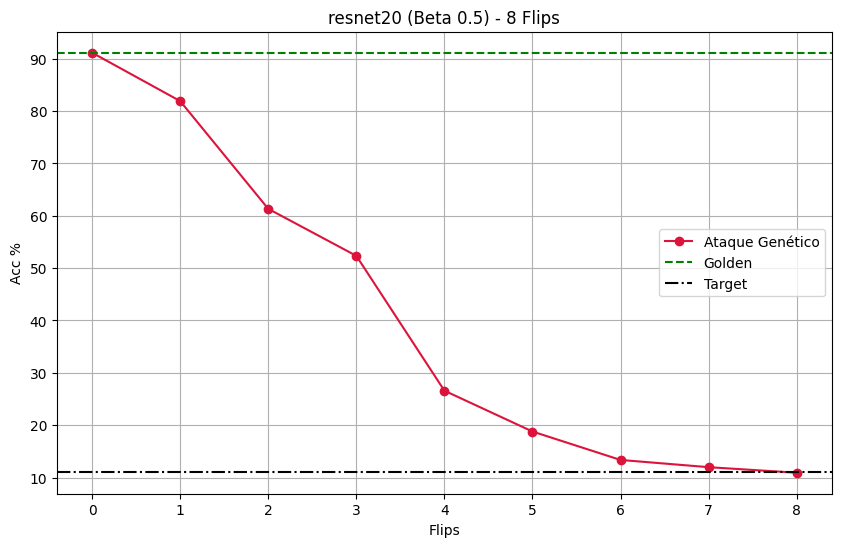


INICIANDO EXECUÇÃO OTIMIZADA: resnet20, Beta=1.0

Acc Golden: 91.15% | Acc Quant(0 flips): 91.15%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 28.84% | Flips: 9
Gen 2: New Best! Full Acc: 24.59% | Flips: 9
Gen 3: New Best! Full Acc: 23.97% | Flips: 9
Gen 4: New Best! Full Acc: 24.53% | Flips: 9
Gen 5: New Best! Full Acc: 28.84% | Flips: 9
Gen 7: New Best! Full Acc: 18.26% | Flips: 9
Gen 9: New Best! Full Acc: 25.69% | Flips: 9
Gen 11: New Best! Full Acc: 17.26% | Flips: 9
Gen 13: New Best! Full Acc: 14.34% | Flips: 9
Gen 16: New Best! Full Acc: 13.96% | Flips: 9
Gen 24: New Best! Full Acc: 10.99% | Flips: 9
>>> TARGET ATINGIDO <<<
AG Time: 13.05s

--- PRUNE (Fast Mode) ---
[PRUNE] ⛔ Não foi possível reduzir de 9 mantendo target.
Gerando Plot...


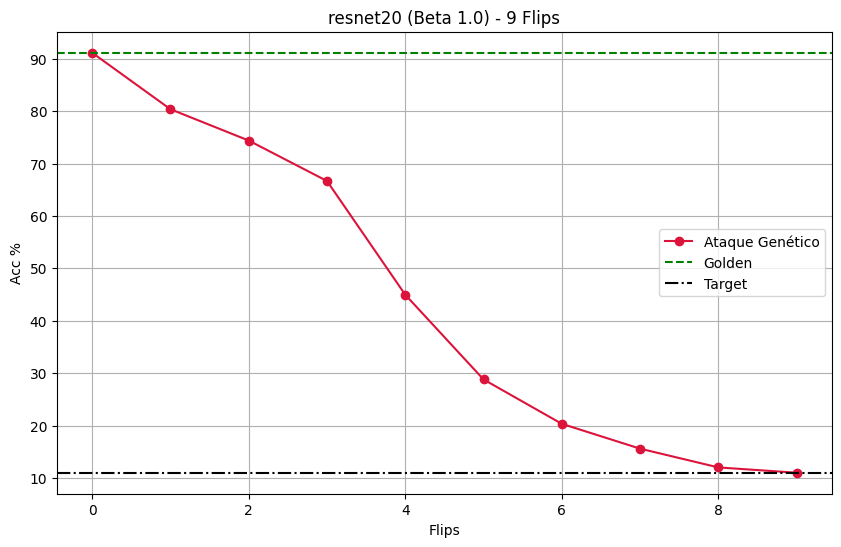


INICIANDO EXECUÇÃO OTIMIZADA: resnet20, Beta=2.3

Acc Golden: 91.15% | Acc Quant(0 flips): 91.15%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 47.23% | Flips: 8
Gen 2: New Best! Full Acc: 29.08% | Flips: 9
Gen 4: New Best! Full Acc: 14.17% | Flips: 9
Gen 5: New Best! Full Acc: 30.01% | Flips: 9
Gen 7: New Best! Full Acc: 28.49% | Flips: 9
Gen 11: New Best! Full Acc: 15.14% | Flips: 9
Gen 17: New Best! Full Acc: 11.79% | Flips: 9
Gen 22: New Best! Full Acc: 21.13% | Flips: 9
Gen 30: New Best! Full Acc: 12.41% | Flips: 9
Gen 31: New Best! Full Acc: 10.57% | Flips: 9
>>> TARGET ATINGIDO <<<
AG Time: 15.56s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 9 -> 8 | acc=10.35%
[PRUNE] ✅ Redução: 8 -> 7 | acc=10.35%
[PRUNE] ⛔ Não foi possível reduzir de 7 mantendo target.
Pruned: 9 -> 7
Gerando Plot...


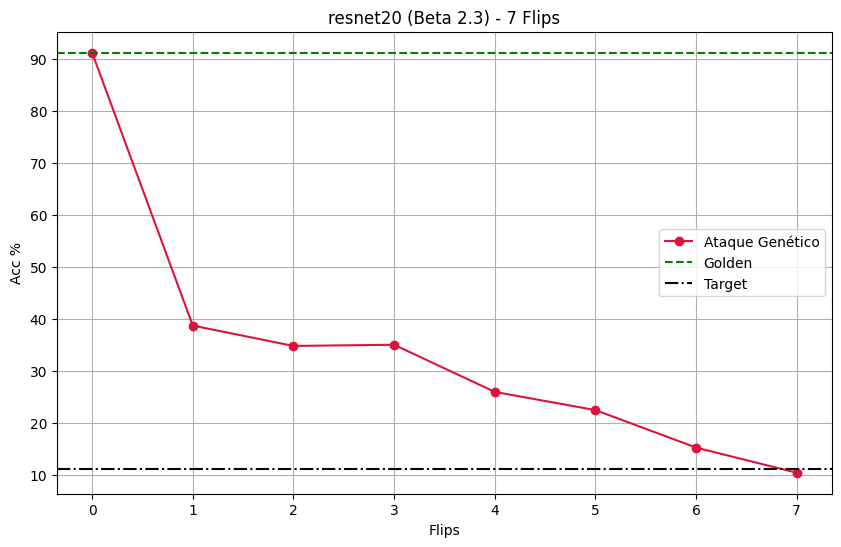


INICIANDO EXECUÇÃO OTIMIZADA: resnet20, Beta=3.0

Acc Golden: 91.15% | Acc Quant(0 flips): 91.15%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 28.84% | Flips: 9
Gen 2: New Best! Full Acc: 24.59% | Flips: 9
Gen 3: New Best! Full Acc: 23.97% | Flips: 9
Gen 4: New Best! Full Acc: 24.53% | Flips: 9
Gen 5: New Best! Full Acc: 28.84% | Flips: 9
Gen 7: New Best! Full Acc: 18.26% | Flips: 9
Gen 9: New Best! Full Acc: 25.69% | Flips: 9
Gen 11: New Best! Full Acc: 17.26% | Flips: 9
Gen 13: New Best! Full Acc: 14.34% | Flips: 9
Gen 16: New Best! Full Acc: 13.96% | Flips: 9
Gen 24: New Best! Full Acc: 10.99% | Flips: 9
>>> TARGET ATINGIDO <<<
AG Time: 13.01s

--- PRUNE (Fast Mode) ---
[PRUNE] ⛔ Não foi possível reduzir de 9 mantendo target.
Gerando Plot...


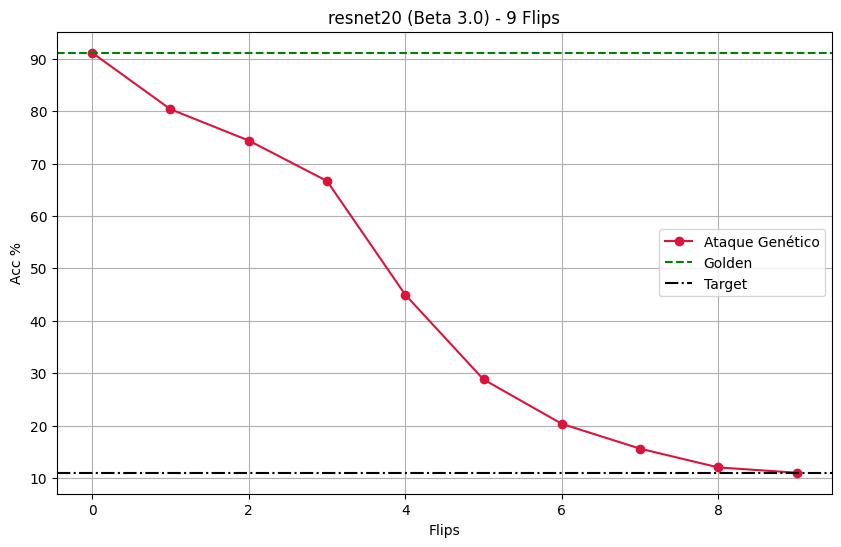


INICIANDO EXECUÇÃO OTIMIZADA: resnet32, Beta=0.5

Acc Golden: 92.23% | Acc Quant(0 flips): 92.23%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 33.78% | Flips: 6
Gen 3: New Best! Full Acc: 25.11% | Flips: 6
Gen 6: New Best! Full Acc: 15.87% | Flips: 6
Gen 10: New Best! Full Acc: 15.24% | Flips: 6
Gen 12: New Best! Full Acc: 13.68% | Flips: 6
Gen 13: New Best! Full Acc: 12.93% | Flips: 6
Gen 14: New Best! Full Acc: 10.97% | Flips: 6
>>> TARGET ATINGIDO <<<
AG Time: 11.59s

--- PRUNE (Fast Mode) ---
[PRUNE] ⛔ Não foi possível reduzir de 6 mantendo target.
Gerando Plot...


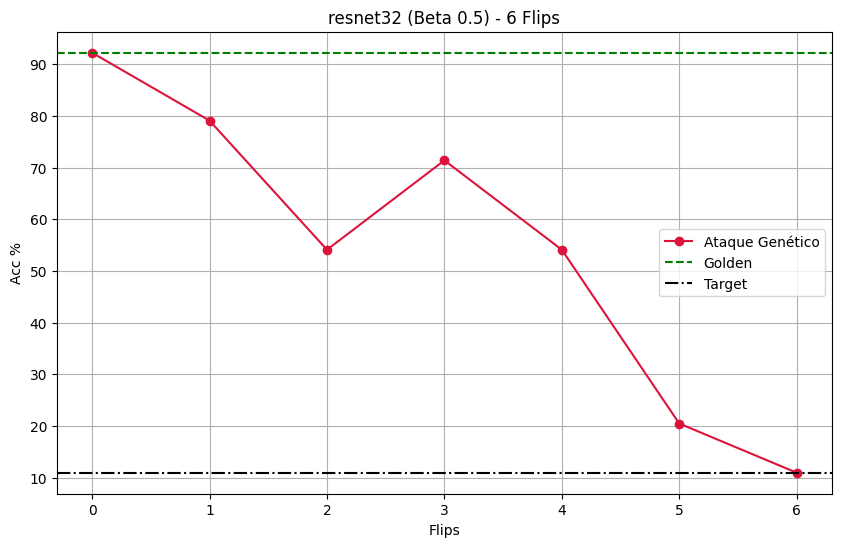


INICIANDO EXECUÇÃO OTIMIZADA: resnet32, Beta=1.0

Acc Golden: 92.23% | Acc Quant(0 flips): 92.23%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 47.65% | Flips: 6
Gen 2: New Best! Full Acc: 65.25% | Flips: 6
Gen 4: New Best! Full Acc: 24.99% | Flips: 6
Gen 6: New Best! Full Acc: 24.60% | Flips: 6
Gen 7: New Best! Full Acc: 22.97% | Flips: 6
Gen 8: New Best! Full Acc: 16.95% | Flips: 6
Gen 11: New Best! Full Acc: 13.49% | Flips: 6
Gen 13: New Best! Full Acc: 12.70% | Flips: 6
Gen 14: New Best! Full Acc: 10.34% | Flips: 6
>>> TARGET ATINGIDO <<<
AG Time: 12.54s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 6 -> 5 | acc=10.34%
[PRUNE] ⛔ Não foi possível reduzir de 5 mantendo target.
Pruned: 6 -> 5
Gerando Plot...


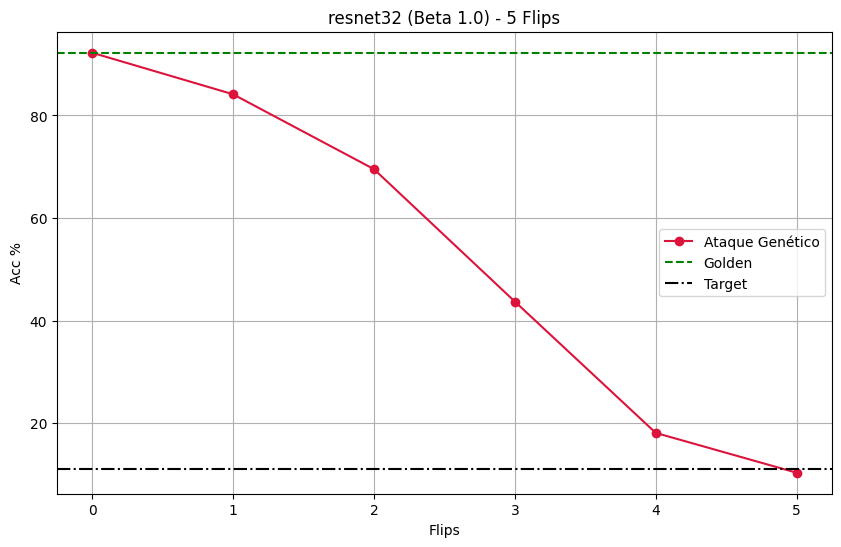


INICIANDO EXECUÇÃO OTIMIZADA: resnet32, Beta=2.3

Acc Golden: 92.23% | Acc Quant(0 flips): 92.23%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 34.28% | Flips: 6
Gen 2: New Best! Full Acc: 35.73% | Flips: 6
Gen 3: New Best! Full Acc: 42.58% | Flips: 6
Gen 4: New Best! Full Acc: 13.89% | Flips: 6
Gen 8: New Best! Full Acc: 11.18% | Flips: 6
Gen 11: New Best! Full Acc: 13.49% | Flips: 6
Gen 12: New Best! Full Acc: 10.68% | Flips: 6
>>> TARGET ATINGIDO <<<
AG Time: 10.15s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 6 -> 5 | acc=10.50%
[PRUNE] ⛔ Não foi possível reduzir de 5 mantendo target.
Pruned: 6 -> 5
Gerando Plot...


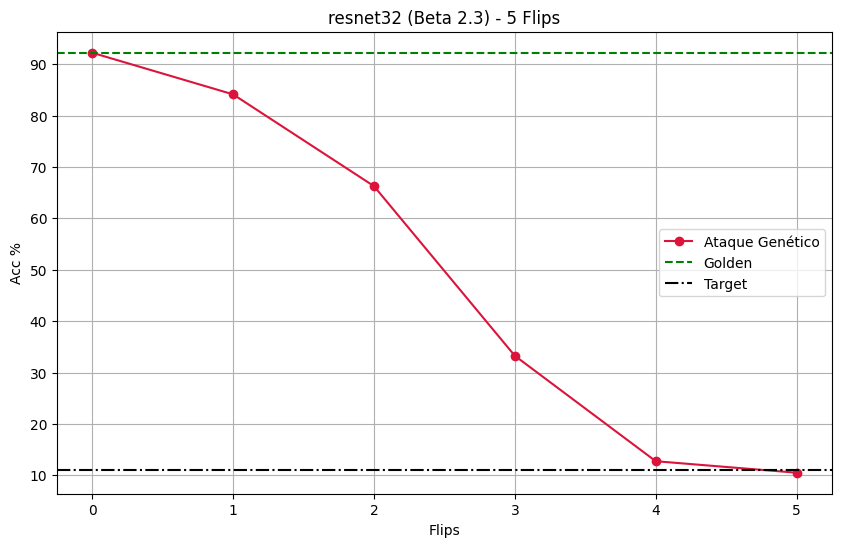


INICIANDO EXECUÇÃO OTIMIZADA: resnet32, Beta=3.0

Acc Golden: 92.23% | Acc Quant(0 flips): 92.23%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 40.62% | Flips: 6
Gen 2: New Best! Full Acc: 16.12% | Flips: 6
Gen 3: New Best! Full Acc: 22.80% | Flips: 6
Gen 6: New Best! Full Acc: 11.47% | Flips: 6
Gen 7: New Best! Full Acc: 13.15% | Flips: 6
Gen 13: New Best! Full Acc: 11.14% | Flips: 6
Gen 16: New Best! Full Acc: 11.55% | Flips: 6
Gen 20: New Best! Full Acc: 10.57% | Flips: 6
>>> TARGET ATINGIDO <<<
AG Time: 14.79s

--- PRUNE (Fast Mode) ---
[PRUNE] ⛔ Não foi possível reduzir de 6 mantendo target.
Gerando Plot...


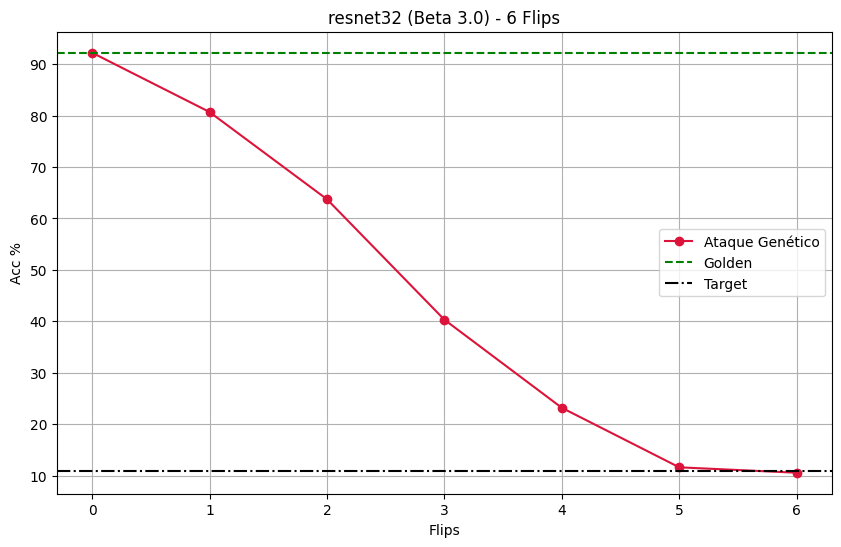


INICIANDO EXECUÇÃO OTIMIZADA: resnet44, Beta=0.5

Acc Golden: 92.62% | Acc Quant(0 flips): 92.62%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 38.88% | Flips: 12
Gen 3: New Best! Full Acc: 31.13% | Flips: 12
Gen 4: New Best! Full Acc: 24.97% | Flips: 12
Gen 5: New Best! Full Acc: 17.26% | Flips: 12
Gen 7: New Best! Full Acc: 22.70% | Flips: 12
Gen 8: New Best! Full Acc: 11.35% | Flips: 12
Gen 10: New Best! Full Acc: 11.33% | Flips: 12
Gen 14: New Best! Full Acc: 10.15% | Flips: 12
>>> TARGET ATINGIDO <<<
AG Time: 15.74s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 12 -> 11 | acc=10.26%
[PRUNE] ✅ Redução: 11 -> 10 | acc=10.51%
[PRUNE] ⛔ Não foi possível reduzir de 10 mantendo target.
Pruned: 12 -> 10
Gerando Plot...


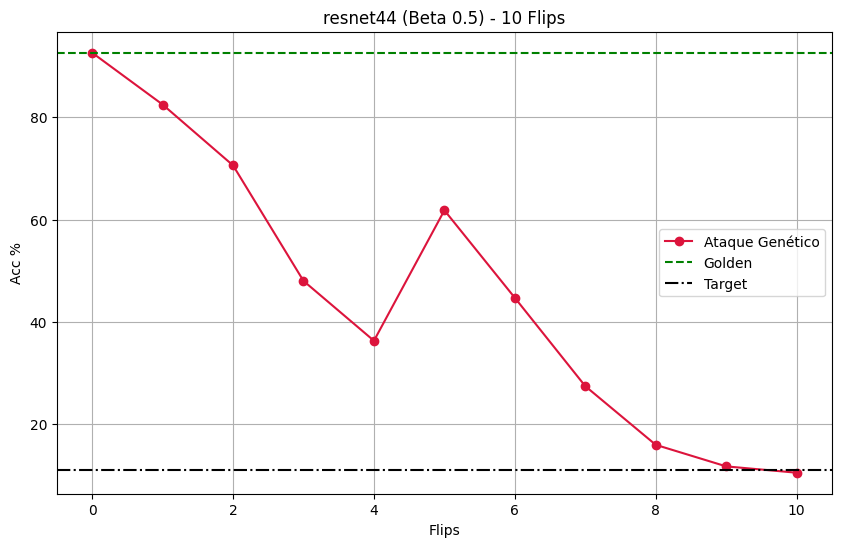


INICIANDO EXECUÇÃO OTIMIZADA: resnet44, Beta=1.0

Acc Golden: 92.62% | Acc Quant(0 flips): 92.62%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 38.88% | Flips: 12
Gen 3: New Best! Full Acc: 31.13% | Flips: 12
Gen 4: New Best! Full Acc: 24.97% | Flips: 12
Gen 5: New Best! Full Acc: 17.26% | Flips: 12
Gen 7: New Best! Full Acc: 22.70% | Flips: 12
Gen 8: New Best! Full Acc: 11.35% | Flips: 12
Gen 10: New Best! Full Acc: 11.33% | Flips: 12
Gen 14: New Best! Full Acc: 10.15% | Flips: 12
>>> TARGET ATINGIDO <<<
AG Time: 15.76s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 12 -> 11 | acc=10.26%
[PRUNE] ✅ Redução: 11 -> 10 | acc=10.51%
[PRUNE] ⛔ Não foi possível reduzir de 10 mantendo target.
Pruned: 12 -> 10
Gerando Plot...


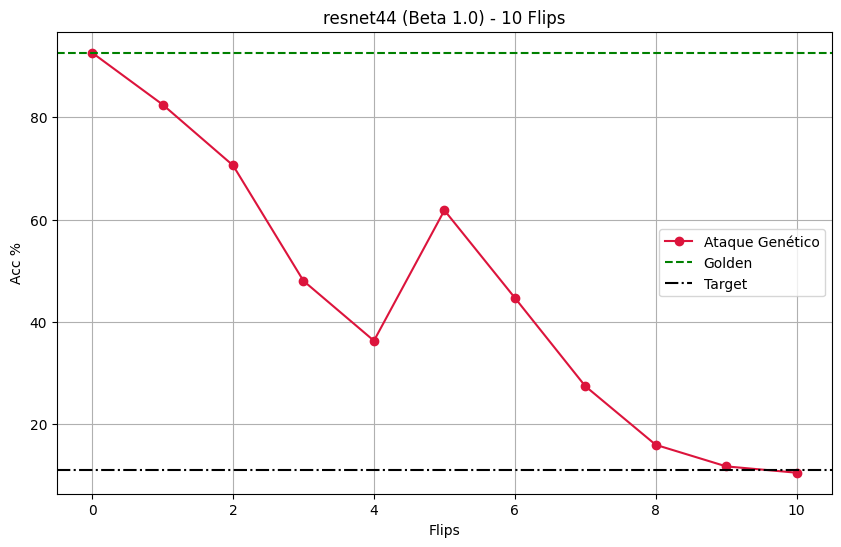


INICIANDO EXECUÇÃO OTIMIZADA: resnet44, Beta=2.3

Acc Golden: 92.62% | Acc Quant(0 flips): 92.62%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 44.95% | Flips: 12
Gen 2: New Best! Full Acc: 58.19% | Flips: 10
Gen 5: New Best! Full Acc: 45.01% | Flips: 12
Gen 7: New Best! Full Acc: 30.00% | Flips: 12
Gen 12: New Best! Full Acc: 17.09% | Flips: 12
Gen 21: New Best! Full Acc: 19.30% | Flips: 12
Gen 49: New Best! Full Acc: 15.85% | Flips: 12
Gen 51: New Best! Full Acc: 29.48% | Flips: 12
AG Time: 54.35s
Gerando Plot...


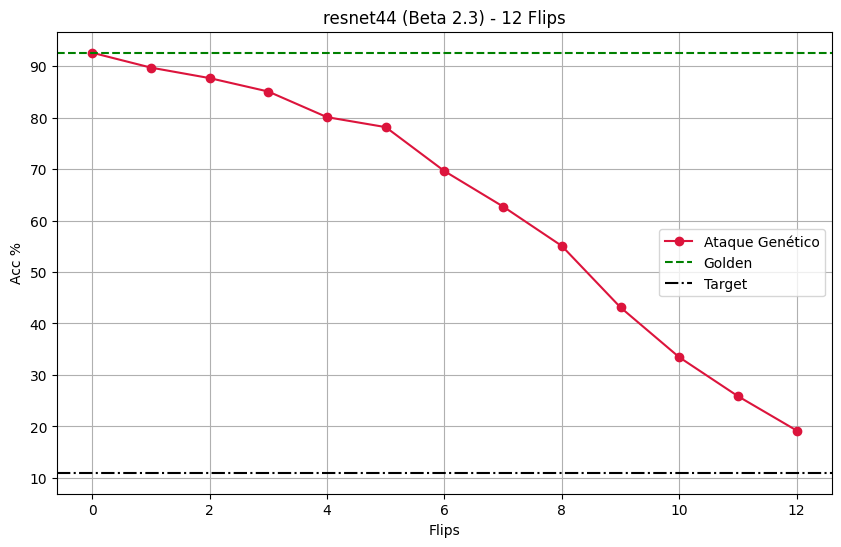


INICIANDO EXECUÇÃO OTIMIZADA: resnet44, Beta=3.0

Acc Golden: 92.62% | Acc Quant(0 flips): 92.62%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 51.77% | Flips: 12
Gen 2: New Best! Full Acc: 66.03% | Flips: 10
Gen 3: New Best! Full Acc: 29.17% | Flips: 12
Gen 5: New Best! Full Acc: 30.41% | Flips: 12
Gen 6: New Best! Full Acc: 35.62% | Flips: 12
Gen 7: New Best! Full Acc: 22.73% | Flips: 12
Gen 9: New Best! Full Acc: 20.28% | Flips: 12
AG Time: 54.51s
Gerando Plot...


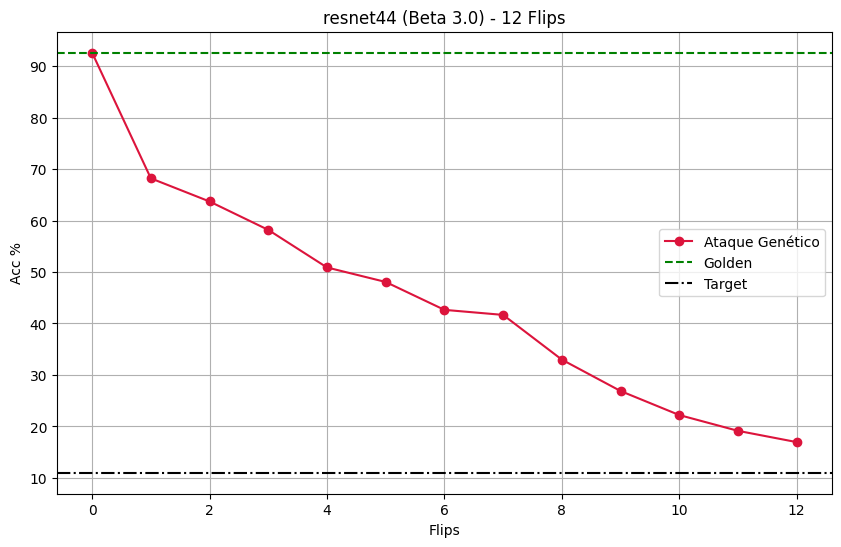


INICIANDO EXECUÇÃO OTIMIZADA: resnet56, Beta=0.5

Acc Golden: 92.28% | Acc Quant(0 flips): 92.28%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 50.08% | Flips: 8
Gen 2: New Best! Full Acc: 63.69% | Flips: 10
Gen 3: New Best! Full Acc: 23.04% | Flips: 10
Gen 5: New Best! Full Acc: 16.87% | Flips: 10
Gen 11: New Best! Full Acc: 23.44% | Flips: 10
Gen 12: New Best! Full Acc: 22.81% | Flips: 10
Gen 21: New Best! Full Acc: 11.70% | Flips: 10
Gen 46: New Best! Full Acc: 11.12% | Flips: 10
Gen 64: New Best! Full Acc: 11.28% | Flips: 10
AG Time: 71.38s
Gerando Plot...


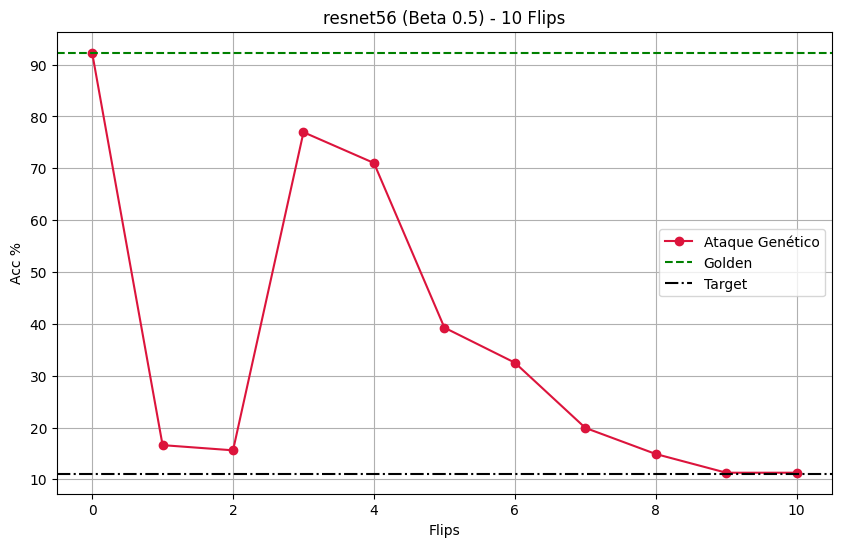


INICIANDO EXECUÇÃO OTIMIZADA: resnet56, Beta=1.0

Acc Golden: 92.28% | Acc Quant(0 flips): 92.28%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 27.32% | Flips: 10
Gen 2: New Best! Full Acc: 28.37% | Flips: 10
Gen 5: New Best! Full Acc: 32.75% | Flips: 10
Gen 7: New Best! Full Acc: 20.53% | Flips: 10
Gen 9: New Best! Full Acc: 22.57% | Flips: 10
Gen 14: New Best! Full Acc: 28.40% | Flips: 10
Gen 19: New Best! Full Acc: 15.57% | Flips: 9
Gen 67: New Best! Full Acc: 27.06% | Flips: 9
AG Time: 67.02s
Gerando Plot...


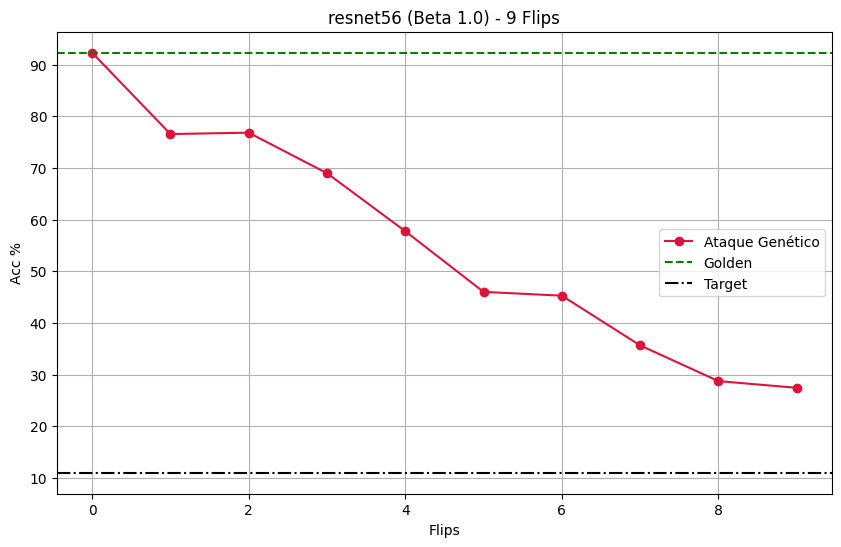


INICIANDO EXECUÇÃO OTIMIZADA: resnet56, Beta=2.3

Acc Golden: 92.28% | Acc Quant(0 flips): 92.28%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 40.17% | Flips: 10
Gen 2: New Best! Full Acc: 52.31% | Flips: 10
Gen 3: New Best! Full Acc: 25.35% | Flips: 10
Gen 4: New Best! Full Acc: 67.85% | Flips: 10
Gen 10: New Best! Full Acc: 38.72% | Flips: 10
Gen 15: New Best! Full Acc: 17.85% | Flips: 9
Gen 36: New Best! Full Acc: 21.27% | Flips: 10
Gen 42: New Best! Full Acc: 26.28% | Flips: 10
AG Time: 66.67s
Gerando Plot...


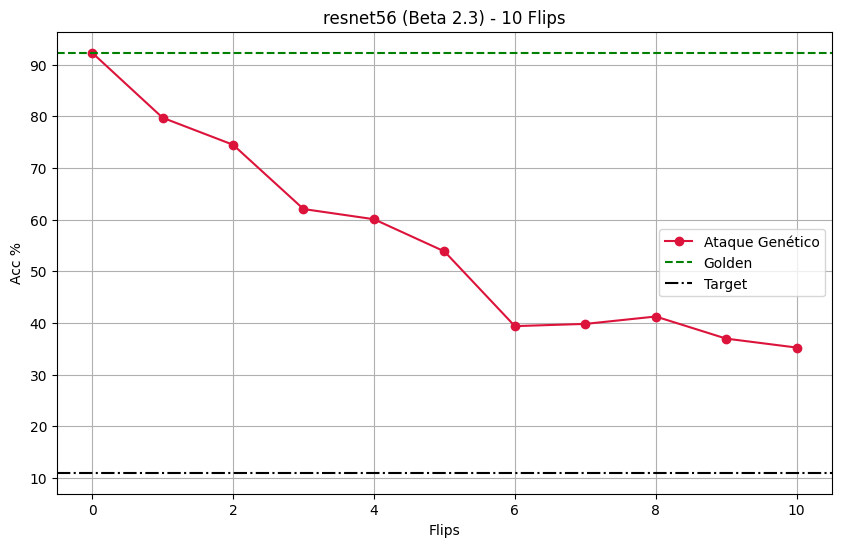


INICIANDO EXECUÇÃO OTIMIZADA: resnet56, Beta=3.0

Acc Golden: 92.28% | Acc Quant(0 flips): 92.28%

--- AG (Fast Mode) ---
Gen 1: New Best! Full Acc: 66.52% | Flips: 10
Gen 2: New Best! Full Acc: 52.21% | Flips: 8
Gen 3: New Best! Full Acc: 26.63% | Flips: 10
Gen 4: New Best! Full Acc: 21.98% | Flips: 9
Gen 5: New Best! Full Acc: 25.33% | Flips: 10
Gen 8: New Best! Full Acc: 21.67% | Flips: 10
Gen 12: New Best! Full Acc: 12.48% | Flips: 10
Gen 13: New Best! Full Acc: 13.61% | Flips: 10
Gen 16: New Best! Full Acc: 9.94% | Flips: 10
>>> TARGET ATINGIDO <<<
AG Time: 21.68s

--- PRUNE (Fast Mode) ---
[PRUNE] ✅ Redução: 10 -> 9 | acc=10.05%
[PRUNE] ⛔ Não foi possível reduzir de 9 mantendo target.
Pruned: 10 -> 9
Gerando Plot...


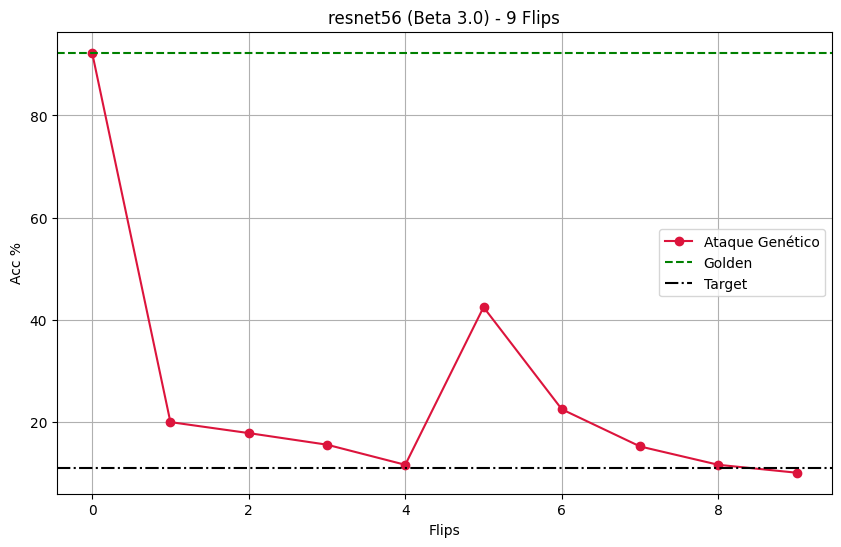


=== FIM OTIMIZADO ===


In [ ]:
# -*- coding: utf-8 -*-
# === Célula Modificada: Injeção com AG + PRUNE (OTIMIZADA / FAST MODE) ===

import copy
import random
import csv
from tqdm import tqdm
import time
import os
from google.colab import drive
import gc
import itertools
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mrfi import MRFI, EasyConfig

# ==============================================================================
# SEÇÃO DE CONFIGURAÇÃO PRINCIPAL
# ==============================================================================
betas_to_process = [0.5, 1.0, 2.3, 3.0]
# ALTERAÇÃO AQUI: Lista completa de arquiteturas para automação
models_to_process = ["resnet20", "resnet32", "resnet44", "resnet56"]

N_INITIAL_CANDIDATES = 120
BATCH_SIZE_GPU = 128
VALIDATION_SUBSET_FRACTION = 0.02

GA_NUM_GENERATIONS = 70
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05

GA_TARGET_ACCURACY = 0.11
BIT_TO_FLIP = 7  # MSB fixo conforme lógica original

# ---------------- PRUNE ----------------
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"   # "high_vuln_first" ou "none"

drive.mount('/content/drive')
DRIVE_INPUT_PATH = "/content/drive/My Drive/extraidos/treino/1024/"
DRIVE_OUTPUT_PATH = "/content/drive/My Drive/extraidos/treino/1024/TESTSSSSSSS-2_RESULTS_genetico_2026_resnet20_8bits"

VULNERABILITY_COLUMN_NAME = "vulnerability_pred"
LAYER_NAME_COLUMN = "layer"
PARAM_INDEX_COLUMN = "param_index"

# ==============================================================================
# FUNÇÕES DE CACHE E OTIMIZAÇÃO (FAST MODE)
# ==============================================================================
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, shuffle=False, num_workers=2, pin_memory=True)
print(f"INFO: DataLoader principal configurado.")

def cache_loader_to_device(loader, device):
    """
    Carrega todo o dataset do loader para a VRAM da GPU como tensores únicos.
    Remove overhead de I/O dentro do loop do AG.
    """
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0).to(device, non_blocking=True)
    Y = torch.cat(ys, dim=0).to(device, non_blocking=True)
    return X, Y

def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    """
    Avaliação ultra-rápida usando dados já na GPU.
    """
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0

    # Processa em mini-batches slices do tensor na GPU para não estourar VRAM
    for i in range(0, total, batch_size):
        xb = X[i:i+batch_size]
        yb = Y[i:i+batch_size]
        out = fi_model(xb)
        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()

    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> Dict[str, dict]:
    """
    Mapeia as camadas do MRFI para acesso rápido, evitando get_submodule repetitivo.
    """
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if not isinstance(module, (nn.Conv2d, nn.Linear)):
            continue
        if not hasattr(module, "FI_config") or module.FI_config is None:
            continue
        if not getattr(module.FI_config, "weights", None):
            continue

        cfg = module.FI_config.weights[0]
        layer_nodes[name] = {
            "name": name,
            "module": module,
            "cfg": cfg,
            "n_params": module.weight.numel(),
            # Argumentos raw para acesso rápido
            "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
            "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: Dict[str, dict], flips_info_list: List[dict]):
    """
    Configura o modelo IN-PLACE (sem deepcopy).
    """
    # 1. Agrupa flips por camada
    flips_by_layer = {}
    for f in flips_info_list:
        ly = f[LAYER_NAME_COLUMN]
        pid = int(f[PARAM_INDEX_COLUMN])
        flips_by_layer.setdefault(ly, []).append(pid)

    # 2. Atualiza configs
    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])

        if not target_positions:
            # Desativa camada se não houver flips
            cfg.enabled = False
        else:
            # Ativa e configura
            cfg.enabled = True

            # Selector: FixPositions
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions

            # ErrorMode: IntFixedBitFlip (Bit 7 conforme original)
            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            # Replica o bit 7 para cada posição (formato lista)
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: Dict[str, dict]):
    """Congela dynamic_range=auto para evitar recálculo."""
    for node in layer_nodes.values():
        module = node["module"]
        cfg = node["cfg"]
        # Se estiver auto, fixa no max(abs(weight))
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                w_max = float(module.weight.abs().max().item())
            q_args["dynamic_range"] = w_max

# ==============================================================================
# AG: OPERADORES
# ==============================================================================
def create_initial_population(pop_size, chromosome_length, initial_flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice(
            [0, 1],
            size=(chromosome_length,),
            p=[1-initial_flip_prob, initial_flip_prob]
        )
        # Corrige excesso de flips
        while np.sum(chromosome) > max_flips:
            one_indices = np.where(chromosome == 1)[0]
            if len(one_indices) > 0:
                idx_to_flip = np.random.choice(one_indices)
                chromosome[idx_to_flip] = 0
            else:
                break
        population.append(chromosome.astype(np.int8)) # Economiza memória
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    idxs = np.where(chromosome == 1)[0]
    return [candidate_pool[i] for i in idxs]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips_to_inject = translate_chromosome_to_flips(chromosome, candidate_pool)

    if not flips_to_inject:
        return 0.0, baseline_acc

    # Configuração rápida in-place
    apply_active_flips_fast(layer_nodes, flips_to_inject)

    # Inferência rápida
    acc_i = eval_acc_fast(fi_model, cached_data)

    # Reset para baseline limpo não é estritamente necessário se sobrescrevermos tudo
    # mas garante consistência na próxima iteração
    # (Otimização: apply_active_flips_fast já lida com desativação)

    return baseline_acc - acc_i, acc_i

def selection(population_with_fitness, tournament_size):
    # Otimização: sample de indices ao invés de objetos pesados se possível,
    # mas aqui lista de tuplas é leve
    contenders = random.sample(population_with_fitness, min(tournament_size, len(population_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(parent1, parent2, max_flips):
    if len(parent1) < 2:
        return parent1.copy(), parent2.copy()

    cpoint = random.randint(1, len(parent1) - 1)
    child1 = np.concatenate([parent1[:cpoint], parent2[cpoint:]])
    child2 = np.concatenate([parent2[:cpoint], parent1[cpoint:]])

    for child in [child1, child2]:
        while np.sum(child) > max_flips:
            one_indices = np.where(child == 1)[0]
            if len(one_indices) > 0:
                idx = np.random.choice(one_indices)
                child[idx] = 0
            else:
                break
    return child1, child2

def mutation(chromosome, mutation_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mutation_rate
    mutated = chromosome.copy()
    # Flip bits
    mutated[mask] = 1 - mutated[mask]

    # Corrige constraint
    if np.sum(mutated) > max_flips:
        # Reverte aleatoriamente excessos ou simplesmente desliga excessos
        # Abordagem simples: desliga aleatórios até satisfazer
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0:
            remove_idxs = np.random.choice(ones, to_remove, replace=False)
            mutated[remove_idxs] = 0

    return mutated

# =========================
# PRUNE OTIMIZADO
# =========================
def prune_flip_set_keep_target_fast(
    layer_nodes,
    fi_model,
    flips_list,
    cached_data,
    target_acc,
    order="low_vuln_first",
    verbose=True
):
    if flips_list is None or len(flips_list) <= 1:
        return flips_list

    # Verifica acc inicial
    apply_active_flips_fast(layer_nodes, flips_list)
    acc0 = eval_acc_fast(fi_model, cached_data)

    if acc0 >= target_acc:
        if verbose:
            print(f"[PRUNE] Solução atual NÃO atinge target (acc={acc0*100:.2f}%). PRUNE cancelado.")
        return flips_list

    current = flips_list[:]

    def vuln_of(f):
        return float(f.get(VULNERABILITY_COLUMN_NAME, 0.0))

    # Loop de redução
    while len(current) > 1:
        n = len(current)

        # Define ordem de teste
        if order == "low_vuln_first":
            ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        elif order == "high_vuln_first":
            ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=True)
        else:
            ordered_indices = list(range(n))

        best_trial = None
        best_trial_acc = None

        # Testa remover 1 flip por vez (Exaustivo N-1)
        # AQUI ESTA O GANHO: Configuração e inferência in-place
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]

            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)

            # Se mantém o dano (acc < target), é candidato
            if acc_t < target_acc:
                # Queremos o que tem MENOR acc (mais robusto no ataque) ou tanto faz?
                # Geralmente queremos a menor acc possível com menos flips.
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc = acc_t
                    best_trial = trial

        if best_trial is not None:
            if verbose:
                print(f"[PRUNE] ✅ Redução: {len(current)} -> {len(best_trial)} | acc={best_trial_acc*100:.2f}%")
            current = best_trial
        else:
            if verbose:
                print(f"[PRUNE] ⛔ Não foi possível reduzir de {len(current)} mantendo target.")
            break

    return current

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
    print(f"INFO: Relatórios e gráficos serão salvos em: {DRIVE_OUTPUT_PATH}")

    # Prepara cache da GPU uma única vez para o dataset completo
    # (Usado na avaliação final e no prune)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: Usando dispositivo: {device}")

    print("INFO: Criando cache do dataset de teste na GPU...")
    full_cached_data = cache_loader_to_device(test_loader, device)

    # Cria subconjunto de validação para o AG (Cacheado também)
    num_subset_samples = 256
    subset_indices = np.random.choice(len(test_ds), num_subset_samples, replace=False)
    # Criamos um loader temporário só para extrair os dados
    temp_subset_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE_GPU, sampler=SubsetRandomSampler(subset_indices)
    )
    ga_cached_data = cache_loader_to_device(temp_subset_loader, device)
    print(f"INFO: Cache de validação do AG criado ({num_subset_samples} amostras).")

    for model_name in models_to_process:
        GA_MAX_FLIPS = 0
        model_cpu = None

        if model_name == "resnet20":
            model_cpu = ResNet20(num_classes=10)
            GA_MAX_FLIPS = 9
        elif model_name == "resnet32":
            model_cpu = ResNet32(num_classes=10)
            GA_MAX_FLIPS = 6
        elif model_name == "resnet44":
            model_cpu = ResNet44(num_classes=10)
            GA_MAX_FLIPS = 12
        elif model_name == "resnet56":
            model_cpu = ResNet56(num_classes=10)
            GA_MAX_FLIPS = 10

        if model_cpu is None: continue

        for beta_value in betas_to_process:
            print("\n" + "="*80)
            print(f"INICIANDO EXECUÇÃO OTIMIZADA: {model_name}, Beta={beta_value}")
            print("="*80 + "\n")

            # Paths e nomes
            vulnerability_csv_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_predicoes_com_modelo_f{beta_value}_1024_8.csv")
            model_weights_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_cifar10.pth")
            final_report_name = f"relatorio_ag_{model_name}_beta{beta_value}.txt"
            degradation_plot_name = f"grafico_ag_{model_name}_beta{beta_value}.png"
            best_flips_csv_name = f"best_flips_final_ag_{model_name}_beta{beta_value}.csv"

            # Seeds
            torch.manual_seed(0)
            random.seed(0)
            np.random.seed(0)
            if torch.cuda.is_available(): torch.cuda.manual_seed_all(0)

            # 1. Carregar Modelo Pytorch
            try:
                model_cpu.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
            except Exception as e:
                print(f"ERRO PESOS: {e}"); continue
            model_cpu.eval()

            # 2. Ler CSV de candidatos
            try:
                # Leitura otimizada com chunks
                with open(vulnerability_csv_path) as f: total_rows = sum(1 for line in f) - 1
                chunk_size = (total_rows // 2) + 1 if total_rows > 0 else 1
                chunks = pd.read_csv(vulnerability_csv_path, chunksize=chunk_size,
                                     usecols=[LAYER_NAME_COLUMN, PARAM_INDEX_COLUMN, VULNERABILITY_COLUMN_NAME],
                                     dtype={VULNERABILITY_COLUMN_NAME: np.float32})
                top_list = [c.nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME) for c in chunks]
                df_candidates = pd.concat(top_list).nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME)
                del chunks, top_list; gc.collect()
            except Exception as e:
                print(f"ERRO CSV: {e}"); continue

            candidate_params_pool = [row.to_dict() for _, row in df_candidates.iterrows()]
            if not candidate_params_pool: continue

            # 3. Preparar MRFI (UMA ÚNICA VEZ)
            # Config base
            mrfi_config = EasyConfig.load_string(r"""
            faultinject:
              - type: weight
                enabled: False
                quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
                error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
                selector: {method: RandomPositionByNumber, n: 1}
                module_type: [Conv2d, Linear]
            """)

            # Instancia na GPU
            model_gpu = copy.deepcopy(model_cpu).to(device)
            fi_model = MRFI(model_gpu, mrfi_config)

            # Coleta referências rápidas e congela ranges
            layer_nodes = collect_weight_fi_layers(fi_model)
            freeze_dynamic_ranges(layer_nodes)

            # 4. Avaliar Baseline (Uma única vez)
            apply_active_flips_fast(layer_nodes, []) # Garante 0 flips

            # Baseline Real (sem quantização)
            acc_true_golden = eval_acc_fast(fi_model.model, full_cached_data) # Usa o modelo interno sem wrapper para true golden

            # Baseline Quantizada (0 flips)
            acc_g_quant_baseline = eval_acc_fast(fi_model, full_cached_data)

            # Baseline no subset do AG
            acc_baseline_subset = eval_acc_fast(fi_model, ga_cached_data)

            print(f"Acc Golden: {acc_true_golden*100:.2f}% | Acc Quant(0 flips): {acc_g_quant_baseline*100:.2f}%")

            # 5. Loop AG
            print(f"\n--- AG (Fast Mode) ---")
            start_time = time.time()

            population = create_initial_population(
                GA_POPULATION_SIZE, len(candidate_params_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS
            )

            best_overall_chrom = None
            best_overall_fit = -999.0

            for gen in range(GA_NUM_GENERATIONS):
                pop_fit = []

                # Loop de fitness (Agora ultra-rápido)
                for chrom in population: # Sem tqdm por indivíduo para não poluir, o loop é rápido
                    fit, acc_sub = evaluate_fitness_fast(
                        chrom, candidate_params_pool, layer_nodes, fi_model, ga_cached_data, acc_baseline_subset
                    )
                    pop_fit.append((fit, acc_sub, chrom))

                pop_fit.sort(key=lambda x: x[0], reverse=True)
                gen_best_fit, _, gen_best_chrom = pop_fit[0]

                # Check Global Best
                if gen_best_fit > best_overall_fit:
                    best_overall_fit = gen_best_fit
                    best_overall_chrom = gen_best_chrom.copy()

                    # Validação cruzada no Full Set (Otimizada)
                    best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                    apply_active_flips_fast(layer_nodes, best_flips_tmp)
                    acc_full = eval_acc_fast(fi_model, full_cached_data)

                    n_flips = int(np.sum(best_overall_chrom))
                    print(f"Gen {gen+1}: New Best! Full Acc: {acc_full*100:.2f}% | Flips: {n_flips}")

                    if acc_full < GA_TARGET_ACCURACY:
                        print(">>> TARGET ATINGIDO <<<")
                        break

                # Evolução
                new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
                while len(new_pop) < GA_POPULATION_SIZE:
                    p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
                    new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
                    if len(new_pop) < GA_POPULATION_SIZE:
                        new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
                population = new_pop

            total_time = time.time() - start_time
            print(f"AG Time: {total_time:.2f}s")

            # 6. Pós-Processamento e Prune
            if best_overall_chrom is not None:
                best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)

                # Verifica acc final
                apply_active_flips_fast(layer_nodes, best_flips)
                final_acc = eval_acc_fast(fi_model, full_cached_data)

                pruned_flag = False
                n_before = len(best_flips)

                if GA_ENABLE_POST_PRUNING and (final_acc < GA_TARGET_ACCURACY) and (len(best_flips) > 1):
                    print(f"\n--- PRUNE (Fast Mode) ---")
                    best_flips_pruned = prune_flip_set_keep_target_fast(
                        layer_nodes, fi_model, best_flips, full_cached_data, GA_TARGET_ACCURACY, GA_PRUNE_ORDER
                    )

                    if len(best_flips_pruned) < len(best_flips):
                        apply_active_flips_fast(layer_nodes, best_flips_pruned)
                        acc_pruned = eval_acc_fast(fi_model, full_cached_data)
                        if acc_pruned < GA_TARGET_ACCURACY:
                            best_flips = best_flips_pruned
                            final_acc = acc_pruned
                            pruned_flag = True
                            print(f"Pruned: {n_before} -> {len(best_flips)}")

                # 7. Salvar CSV
                df_res = pd.DataFrame(best_flips)
                if VULNERABILITY_COLUMN_NAME in df_res:
                    df_res = df_res.sort_values(VULNERABILITY_COLUMN_NAME, ascending=False)
                df_res.to_csv(os.path.join(DRIVE_OUTPUT_PATH, best_flips_csv_name), index=False)

                # 8. Relatório
                report = [
                    f"MODEL: {model_name} | BETA: {beta_value}",
                    f"Golden Acc: {acc_true_golden*100:.2f}%",
                    f"Final Acc: {final_acc*100:.2f}%",
                    f"Flips Used: {len(best_flips)}",
                    f"Pruned: {pruned_flag}",
                    f"Target: {GA_TARGET_ACCURACY*100}%",
                    f"Time: {total_time:.2f}s"
                ]
                with open(os.path.join(DRIVE_OUTPUT_PATH, final_report_name), 'w') as f:
                    f.write("\n".join(report))

                # 9. Plot Degradação (Usando método rápido)
                print("Gerando Plot...")
                accs = [acc_g_quant_baseline]
                xs = [0]

                # Ordena por vulnerabilidade para o plot ficar bonito (acumulativo)
                sorted_flips = sorted(best_flips, key=lambda x: x.get(VULNERABILITY_COLUMN_NAME, 0), reverse=True)

                for k in range(1, len(sorted_flips) + 1):
                    apply_active_flips_fast(layer_nodes, sorted_flips[:k])
                    accs.append(eval_acc_fast(fi_model, full_cached_data))
                    xs.append(k)

                plt.figure(figsize=(10,6))
                plt.plot(xs, [a*100 for a in accs], marker='o', color='crimson', label='Ataque Genético')
                plt.axhline(acc_true_golden*100, color='green', linestyle='--', label='Golden')
                plt.axhline(GA_TARGET_ACCURACY*100, color='black', linestyle='-.', label='Target')
                plt.title(f"{model_name} (Beta {beta_value}) - {len(best_flips)} Flips")
                plt.xlabel("Flips")
                plt.ylabel("Acc %")
                plt.legend()
                plt.grid(True)
                plt.savefig(os.path.join(DRIVE_OUTPUT_PATH, degradation_plot_name))
                plt.show()

            # Limpeza final
            del fi_model, layer_nodes, model_gpu
            gc.collect()
            torch.cuda.empty_cache()

    print("\n=== FIM OTIMIZADO ===")

O DETERMINISTICO É ESSE DE BAIXO

In [ ]:
# -*- coding: utf-8 -*-
# === Célula Modificada: Injeção com AG + PRUNE (OTIMIZADA / FAST MODE / DETERMINÍSTICA) ===

import copy
import random
import csv
from tqdm import tqdm
import time
import os
from google.colab import drive
import gc
import itertools
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mrfi import MRFI, EasyConfig

# ==============================================================================
# 0. FUNÇÃO DE REPRODUTIBILIDADE (CRÍTICO PARA EVITAR VARIAÇÃO)
# ==============================================================================
def set_deterministic(seed=42):
    """
    Fixa todas as seeds e configura a GPU para modo determinístico.
    Isso garante que rodar o código 2x gere exatamente o mesmo resultado.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Configurações do cuDNN para garantir repetibilidade em GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Variável de ambiente para operações determinísticas do algoritmo
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    # Tenta forçar algoritmos determinísticos no PyTorch (se versão compatível)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass

# ==============================================================================
# SEÇÃO DE CONFIGURAÇÃO PRINCIPAL
# ==============================================================================
betas_to_process = [0.5, 1.0, 2.3, 3.0]
models_to_process = ["resnet20", "resnet32", "resnet44", "resnet56"]

N_INITIAL_CANDIDATES = 120
BATCH_SIZE_GPU = 128
VALIDATION_SUBSET_FRACTION = 0.02 # Pequeno subset para o AG

GA_NUM_GENERATIONS = 70
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05

GA_TARGET_ACCURACY = 0.11
BIT_TO_FLIP = 7  # MSB para 8 bits (índice 7)

# ---------------- PRUNE ----------------
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

drive.mount('/content/drive')
DRIVE_INPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/"
DRIVE_OUTPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/RESULTS_genetico_2026_resnet20_8bits_BEST"

VULNERABILITY_COLUMN_NAME = "vulnerability_pred"
LAYER_NAME_COLUMN = "layer"
PARAM_INDEX_COLUMN = "param_index"

# ==============================================================================
# FUNÇÕES DE CACHE E OTIMIZAÇÃO (FAST MODE)
# ==============================================================================
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
# Importante: download=True pode variar, idealmente o dataset já existe
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, shuffle=False, num_workers=2, pin_memory=True)
print(f"INFO: DataLoader principal configurado.")

def cache_loader_to_device(loader, device):
    """Carrega dataset para VRAM."""
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0).to(device, non_blocking=True)
    Y = torch.cat(ys, dim=0).to(device, non_blocking=True)
    return X, Y

def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    """Avaliação rápida na GPU."""
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    for i in range(0, total, batch_size):
        xb = X[i:i+batch_size]
        yb = Y[i:i+batch_size]
        out = fi_model(xb)
        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> Dict[str, dict]:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if not isinstance(module, (nn.Conv2d, nn.Linear)): continue
        if not hasattr(module, "FI_config") or module.FI_config is None: continue
        if not getattr(module.FI_config, "weights", None): continue

        cfg = module.FI_config.weights[0]
        layer_nodes[name] = {
            "name": name, "module": module, "cfg": cfg,
            "n_params": module.weight.numel(),
            "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
            "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: Dict[str, dict], flips_info_list: List[dict]):
    """Configura o modelo IN-PLACE."""
    flips_by_layer = {}
    for f in flips_info_list:
        ly = f[LAYER_NAME_COLUMN]
        pid = int(f[PARAM_INDEX_COLUMN])
        flips_by_layer.setdefault(ly, []).append(pid)

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])

        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions

            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: Dict[str, dict]):
    """Congela dynamic_range=auto."""
    for node in layer_nodes.values():
        module = node["module"]
        cfg = node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                w_max = float(module.weight.abs().max().item())
            q_args["dynamic_range"] = w_max

# ==============================================================================
# AG: OPERADORES
# ==============================================================================
def create_initial_population(pop_size, chromosome_length, initial_flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice([0, 1], size=(chromosome_length,), p=[1-initial_flip_prob, initial_flip_prob])
        while np.sum(chromosome) > max_flips:
            one_indices = np.where(chromosome == 1)[0]
            if len(one_indices) > 0:
                idx = np.random.choice(one_indices)
                chromosome[idx] = 0
            else: break
        population.append(chromosome.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    idxs = np.where(chromosome == 1)[0]
    return [candidate_pool[i] for i in idxs]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips_to_inject = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips_to_inject: return 0.0, baseline_acc

    apply_active_flips_fast(layer_nodes, flips_to_inject)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(population_with_fitness, tournament_size):
    contenders = random.sample(population_with_fitness, min(tournament_size, len(population_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(parent1, parent2, max_flips):
    if len(parent1) < 2: return parent1.copy(), parent2.copy()
    cpoint = random.randint(1, len(parent1) - 1)
    c1 = np.concatenate([parent1[:cpoint], parent2[cpoint:]])
    c2 = np.concatenate([parent2[:cpoint], parent1[cpoint:]])

    # CORREÇÃO AQUI: Usar c1 e c2, não child1/child2
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mutation_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mutation_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0:
            remove_idxs = np.random.choice(ones, to_remove, replace=False)
            mutated[remove_idxs] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if flips_list is None or len(flips_list) <= 1: return flips_list

    apply_active_flips_fast(layer_nodes, flips_list)
    acc0 = eval_acc_fast(fi_model, cached_data)
    if acc0 >= target_acc:
        if verbose: print(f"[PRUNE] Solução atual (acc={acc0*100:.2f}%) >= Target. Cancelado.")
        return flips_list

    current = flips_list[:]
    def vuln_of(f): return float(f.get(VULNERABILITY_COLUMN_NAME, 0.0))

    while len(current) > 1:
        n = len(current)
        if order == "low_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        elif order == "high_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=True)
        else: ordered_indices = list(range(n))

        best_trial, best_trial_acc = None, None
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc = acc_t
                    best_trial = trial

        if best_trial is not None:
            if verbose: print(f"[PRUNE] ✅ Redução: {len(current)} -> {len(best_trial)} | acc={best_trial_acc*100:.2f}%")
            current = best_trial
        else:
            if verbose: print(f"[PRUNE] ⛔ Fim da redução.")
            break
    return current

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    # --- 1. DETERMINISMO GLOBAL INICIAL ---
    set_deterministic(0)

    os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
    print(f"INFO: Resultados em: {DRIVE_OUTPUT_PATH}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: Device: {device}")

    # --- 2. CARREGAMENTO DE DADOS (DETERMINÍSTICO) ---
    print("INFO: Cache Full na GPU...")
    full_cached_data = cache_loader_to_device(test_loader, device)

    # Cria subset para o AG. Como a seed está fixa em 0, os índices serão SEMPRE os mesmos.
    num_subset_samples = 256
    subset_indices = np.random.choice(len(test_ds), num_subset_samples, replace=False)
    temp_subset_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, sampler=SubsetRandomSampler(subset_indices))
    ga_cached_data = cache_loader_to_device(temp_subset_loader, device)
    print(f"INFO: Cache AG criado ({num_subset_samples} amostras).")

    for model_name in models_to_process:
        GA_MAX_FLIPS = 0
        model_cpu = None
        if model_name == "resnet20": model_cpu = ResNet20(num_classes=10); GA_MAX_FLIPS = 9
        elif model_name == "resnet32": model_cpu = ResNet32(num_classes=10); GA_MAX_FLIPS = 6
        elif model_name == "resnet44": model_cpu = ResNet44(num_classes=10); GA_MAX_FLIPS = 12
        elif model_name == "resnet56": model_cpu = ResNet56(num_classes=10); GA_MAX_FLIPS = 10
        if model_cpu is None: continue

        for beta_value in betas_to_process:
            # --- 3. DETERMINISMO LOCAL (RESET PARA CADA EXPERIMENTO) ---
            set_deterministic(0)

            print("\n" + "="*80)
            print(f"INICIANDO (DETERMINÍSTICO): {model_name}, Beta={beta_value}")
            print("="*80 + "\n")

            vulnerability_csv_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_predicoes_com_modelo_f{beta_value}_2024_8.csv")
            model_weights_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_cifar10.pth")
            final_report_name = f"relatorio_ag_{model_name}_beta{beta_value}.txt"
            degradation_plot_name = f"grafico_ag_{model_name}_beta{beta_value}.png"
            best_flips_csv_name = f"best_flips_final_ag_{model_name}_beta{beta_value}.csv"

            # Carregar Pesos
            try:
                model_cpu.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
            except Exception as e: print(f"ERRO PESOS: {e}"); continue
            model_cpu.eval()

            # Ler CSV
            try:
                with open(vulnerability_csv_path) as f: total_rows = sum(1 for line in f) - 1
                chunk_size = (total_rows // 2) + 1 if total_rows > 0 else 1
                chunks = pd.read_csv(vulnerability_csv_path, chunksize=chunk_size,
                                     usecols=[LAYER_NAME_COLUMN, PARAM_INDEX_COLUMN, VULNERABILITY_COLUMN_NAME],
                                     dtype={VULNERABILITY_COLUMN_NAME: np.float32})
                top_list = [c.nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME) for c in chunks]
                df_candidates = pd.concat(top_list).nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME)
                del chunks, top_list; gc.collect()
            except Exception as e: print(f"ERRO CSV: {e}"); continue

            candidate_params_pool = [row.to_dict() for _, row in df_candidates.iterrows()]
            if not candidate_params_pool: continue

            # Preparar MRFI
            mrfi_config = EasyConfig.load_string(r"""
            faultinject:
              - type: weight
                enabled: False
                quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
                error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
                selector: {method: RandomPositionByNumber, n: 1}
                module_type: [Conv2d, Linear]
            """)
            model_gpu = copy.deepcopy(model_cpu).to(device)
            fi_model = MRFI(model_gpu, mrfi_config)
            layer_nodes = collect_weight_fi_layers(fi_model)
            freeze_dynamic_ranges(layer_nodes)

            # Baselines
            apply_active_flips_fast(layer_nodes, [])
            acc_true_golden = eval_acc_fast(fi_model.model, full_cached_data)
            acc_g_quant_baseline = eval_acc_fast(fi_model, full_cached_data)
            acc_baseline_subset = eval_acc_fast(fi_model, ga_cached_data)
            print(f"Golden: {acc_true_golden*100:.2f}% | Baseline: {acc_g_quant_baseline*100:.2f}%")

            # AG
            print(f"\n--- AG (Fast + Deterministic) ---")
            start_time = time.time()
            population = create_initial_population(GA_POPULATION_SIZE, len(candidate_params_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)

            best_overall_chrom = None
            best_overall_fit = -999.0

            for gen in range(GA_NUM_GENERATIONS):
                pop_fit = []
                for chrom in population:
                    fit, acc_sub = evaluate_fitness_fast(chrom, candidate_params_pool, layer_nodes, fi_model, ga_cached_data, acc_baseline_subset)
                    pop_fit.append((fit, acc_sub, chrom))

                pop_fit.sort(key=lambda x: x[0], reverse=True)
                gen_best_fit, _, gen_best_chrom = pop_fit[0]

                if gen_best_fit > best_overall_fit:
                    best_overall_fit = gen_best_fit
                    best_overall_chrom = gen_best_chrom.copy()

                    best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                    apply_active_flips_fast(layer_nodes, best_flips_tmp)
                    acc_full = eval_acc_fast(fi_model, full_cached_data)
                    print(f"Gen {gen+1}: New Best! Full Acc: {acc_full*100:.2f}% | Flips: {int(np.sum(best_overall_chrom))}")
                    if acc_full < GA_TARGET_ACCURACY:
                        print(">>> TARGET ATINGIDO <<<")
                        break

                new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
                while len(new_pop) < GA_POPULATION_SIZE:
                    p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
                    new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
                    if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
                population = new_pop

            total_time = time.time() - start_time

            if best_overall_chrom is not None:
                best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                apply_active_flips_fast(layer_nodes, best_flips)
                final_acc = eval_acc_fast(fi_model, full_cached_data)

                pruned_flag = False
                n_before = len(best_flips)
                if GA_ENABLE_POST_PRUNING and (final_acc < GA_TARGET_ACCURACY) and (len(best_flips) > 1):
                    print(f"\n--- PRUNE ---")
                    best_flips_pruned = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, full_cached_data, GA_TARGET_ACCURACY, GA_PRUNE_ORDER)
                    if len(best_flips_pruned) < len(best_flips):
                        apply_active_flips_fast(layer_nodes, best_flips_pruned)
                        acc_pruned = eval_acc_fast(fi_model, full_cached_data)
                        if acc_pruned < GA_TARGET_ACCURACY:
                            best_flips = best_flips_pruned
                            final_acc = acc_pruned
                            pruned_flag = True
                            print(f"Pruned: {n_before} -> {len(best_flips)}")

                df_res = pd.DataFrame(best_flips)
                if VULNERABILITY_COLUMN_NAME in df_res: df_res = df_res.sort_values(VULNERABILITY_COLUMN_NAME, ascending=False)
                df_res.to_csv(os.path.join(DRIVE_OUTPUT_PATH, best_flips_csv_name), index=False)

                report = [
                    f"MODEL: {model_name} | BETA: {beta_value}",
                    f"Golden Acc: {acc_true_golden*100:.2f}%",
                    f"Final Acc: {final_acc*100:.2f}%",
                    f"Flips: {len(best_flips)}",
                    f"Pruned: {pruned_flag}",
                    f"Time: {total_time:.2f}s"
                ]
                with open(os.path.join(DRIVE_OUTPUT_PATH, final_report_name), 'w') as f: f.write("\n".join(report))

                # Plot
                accs = [acc_g_quant_baseline]
                xs = [0]
                sorted_flips = sorted(best_flips, key=lambda x: x.get(VULNERABILITY_COLUMN_NAME, 0), reverse=True)
                for k in range(1, len(sorted_flips) + 1):
                    apply_active_flips_fast(layer_nodes, sorted_flips[:k])
                    accs.append(eval_acc_fast(fi_model, full_cached_data))
                    xs.append(k)

                plt.figure(figsize=(10,6))
                plt.plot(xs, [a*100 for a in accs], marker='o', color='crimson')
                plt.axhline(acc_true_golden*100, color='green', linestyle='--')
                plt.axhline(GA_TARGET_ACCURACY*100, color='black', linestyle='-.')
                plt.title(f"{model_name} (Beta {beta_value}) - {len(best_flips)} Flips")
                plt.xlabel("Flips"); plt.ylabel("Acc %"); plt.grid(True)
                plt.savefig(os.path.join(DRIVE_OUTPUT_PATH, degradation_plot_name))
                plt.close() # Importante para não acumular plots na memória

            del fi_model, layer_nodes, model_gpu
            gc.collect()
            torch.cuda.empty_cache()

    print("\n=== FIM OTIMIZADO (DETERMINÍSTICO) ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: DataLoader principal configurado.
INFO: Resultados em: /content/drive/My Drive/extraidos/treino/1024/TESTSSSSSSS-2_RESULTS_genetico_2026_resnet20_8bits
INFO: Device: cuda
INFO: Cache Full na GPU...
INFO: Cache AG criado (256 amostras).

INICIANDO (DETERMINÍSTICO): resnet20, Beta=0.5

Golden: 91.15% | Baseline: 91.15%

--- AG (Fast + Deterministic) ---
Gen 1: New Best! Full Acc: 60.23% | Flips: 8
Gen 2: New Best! Full Acc: 28.36% | Flips: 9
Gen 3: New Best! Full Acc: 22.81% | Flips: 9
Gen 5: New Best! Full Acc: 25.94% | Flips: 9
Gen 6: New Best! Full Acc: 35.65% | Flips: 8
Gen 9: New Best! Full Acc: 31.38% | Flips: 9
Gen 17: New Best! Full Acc: 17.69% | Flips: 9
Gen 21: New Best! Full Acc: 25.21% | Flips: 9
Gen 24: New Best! Full Acc: 20.65% | Flips: 9
Gen 32: New Best! Full Acc: 11.51% | Flips: 9
Gen 33: New Best! Full Acc: 13.87% | Flips: 9
Gen 61: New

In [7]:
# -*- coding: utf-8 -*-
# === Célula Modificada: Injeção com AG + PRUNE (OTIMIZADA / FAST MODE / DETERMINÍSTICA) ===

import copy
import random
import csv
from tqdm import tqdm
import time
import os
from google.colab import drive
import gc
import itertools
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mrfi import MRFI, EasyConfig

# ==============================================================================
# 0. FUNÇÃO DE REPRODUTIBILIDADE (CRÍTICO PARA EVITAR VARIAÇÃO)
# ==============================================================================
def set_deterministic(seed=42):
    """
    Fixa todas as seeds e configura a GPU para modo determinístico.
    Isso garante que rodar o código 2x gere exatamente o mesmo resultado.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Configurações do cuDNN para garantir repetibilidade em GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Variável de ambiente para operações determinísticas do algoritmo
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    # Tenta forçar algoritmos determinísticos no PyTorch (se versão compatível)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass

# ==============================================================================
# SEÇÃO DE CONFIGURAÇÃO PRINCIPAL
# ==============================================================================
betas_to_process = [0.5, 1.0, 2.3, 3.0]
models_to_process = ["resnet20", "resnet32", "resnet44", "resnet56"]

N_INITIAL_CANDIDATES = 120
BATCH_SIZE_GPU = 128
VALIDATION_SUBSET_FRACTION = 0.02 # Pequeno subset para o AG

GA_NUM_GENERATIONS = 70
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05

GA_TARGET_ACCURACY = 0.11
BIT_TO_FLIP = 7  # MSB para 8 bits (índice 7)

# ---------------- PRUNE ----------------
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

drive.mount('/content/drive')
DRIVE_INPUT_PATH = "/content/drive/My Drive/extraidos/treino/10000/"
DRIVE_OUTPUT_PATH = "/content/drive/My Drive/extraidos/treino/10000/RESULTS_genetico_2026_resnet_8bits_BEST"

VULNERABILITY_COLUMN_NAME = "vulnerability_pred"
LAYER_NAME_COLUMN = "layer"
PARAM_INDEX_COLUMN = "param_index"

# ==============================================================================
# FUNÇÕES DE CACHE E OTIMIZAÇÃO (FAST MODE)
# ==============================================================================
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
# Importante: download=True pode variar, idealmente o dataset já existe
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, shuffle=False, num_workers=2, pin_memory=True)
print(f"INFO: DataLoader principal configurado.")

def cache_loader_to_device(loader, device):
    """Carrega dataset para VRAM."""
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0).to(device, non_blocking=True)
    Y = torch.cat(ys, dim=0).to(device, non_blocking=True)
    return X, Y

def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    """Avaliação rápida na GPU."""
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    for i in range(0, total, batch_size):
        xb = X[i:i+batch_size]
        yb = Y[i:i+batch_size]
        out = fi_model(xb)
        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> Dict[str, dict]:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if not isinstance(module, (nn.Conv2d, nn.Linear)): continue
        if not hasattr(module, "FI_config") or module.FI_config is None: continue
        if not getattr(module.FI_config, "weights", None): continue

        cfg = module.FI_config.weights[0]
        layer_nodes[name] = {
            "name": name, "module": module, "cfg": cfg,
            "n_params": module.weight.numel(),
            "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
            "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: Dict[str, dict], flips_info_list: List[dict]):
    """Configura o modelo IN-PLACE."""
    flips_by_layer = {}
    for f in flips_info_list:
        ly = f[LAYER_NAME_COLUMN]
        pid = int(f[PARAM_INDEX_COLUMN])
        flips_by_layer.setdefault(ly, []).append(pid)

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])

        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions

            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: Dict[str, dict]):
    """Congela dynamic_range=auto."""
    for node in layer_nodes.values():
        module = node["module"]
        cfg = node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                w_max = float(module.weight.abs().max().item())
            q_args["dynamic_range"] = w_max

# ==============================================================================
# AG: OPERADORES
# ==============================================================================
def create_initial_population(pop_size, chromosome_length, initial_flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice([0, 1], size=(chromosome_length,), p=[1-initial_flip_prob, initial_flip_prob])
        while np.sum(chromosome) > max_flips:
            one_indices = np.where(chromosome == 1)[0]
            if len(one_indices) > 0:
                idx = np.random.choice(one_indices)
                chromosome[idx] = 0
            else: break
        population.append(chromosome.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    idxs = np.where(chromosome == 1)[0]
    return [candidate_pool[i] for i in idxs]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips_to_inject = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips_to_inject: return 0.0, baseline_acc

    apply_active_flips_fast(layer_nodes, flips_to_inject)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(population_with_fitness, tournament_size):
    contenders = random.sample(population_with_fitness, min(tournament_size, len(population_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(parent1, parent2, max_flips):
    if len(parent1) < 2: return parent1.copy(), parent2.copy()
    cpoint = random.randint(1, len(parent1) - 1)
    c1 = np.concatenate([parent1[:cpoint], parent2[cpoint:]])
    c2 = np.concatenate([parent2[:cpoint], parent1[cpoint:]])

    # CORREÇÃO AQUI: Usar c1 e c2, não child1/child2
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mutation_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mutation_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0:
            remove_idxs = np.random.choice(ones, to_remove, replace=False)
            mutated[remove_idxs] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if flips_list is None or len(flips_list) <= 1: return flips_list

    apply_active_flips_fast(layer_nodes, flips_list)
    acc0 = eval_acc_fast(fi_model, cached_data)
    if acc0 >= target_acc:
        if verbose: print(f"[PRUNE] Solução atual (acc={acc0*100:.2f}%) >= Target. Cancelado.")
        return flips_list

    current = flips_list[:]
    def vuln_of(f): return float(f.get(VULNERABILITY_COLUMN_NAME, 0.0))

    while len(current) > 1:
        n = len(current)
        if order == "low_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        elif order == "high_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=True)
        else: ordered_indices = list(range(n))

        best_trial, best_trial_acc = None, None
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc = acc_t
                    best_trial = trial

        if best_trial is not None:
            if verbose: print(f"[PRUNE] ✅ Redução: {len(current)} -> {len(best_trial)} | acc={best_trial_acc*100:.2f}%")
            current = best_trial
        else:
            if verbose: print(f"[PRUNE] ⛔ Fim da redução.")
            break
    return current

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    # --- 1. DETERMINISMO GLOBAL INICIAL ---
    set_deterministic(0)

    os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
    print(f"INFO: Resultados em: {DRIVE_OUTPUT_PATH}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: Device: {device}")

    # --- 2. CARREGAMENTO DE DADOS (DETERMINÍSTICO) ---
    print("INFO: Cache Full na GPU...")
    full_cached_data = cache_loader_to_device(test_loader, device)

    # Cria subset para o AG. Como a seed está fixa em 0, os índices serão SEMPRE os mesmos.
    num_subset_samples = 256
    subset_indices = np.random.choice(len(test_ds), num_subset_samples, replace=False)
    temp_subset_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, sampler=SubsetRandomSampler(subset_indices))
    ga_cached_data = cache_loader_to_device(temp_subset_loader, device)
    print(f"INFO: Cache AG criado ({num_subset_samples} amostras).")

    for model_name in models_to_process:
        GA_MAX_FLIPS = 0
        model_cpu = None
        if model_name == "resnet20": model_cpu = ResNet20(num_classes=10); GA_MAX_FLIPS = 9
        elif model_name == "resnet32": model_cpu = ResNet32(num_classes=10); GA_MAX_FLIPS = 6
        elif model_name == "resnet44": model_cpu = ResNet44(num_classes=10); GA_MAX_FLIPS = 12
        elif model_name == "resnet56": model_cpu = ResNet56(num_classes=10); GA_MAX_FLIPS = 10
        if model_cpu is None: continue

        for beta_value in betas_to_process:
            # --- 3. DETERMINISMO LOCAL (RESET PARA CADA EXPERIMENTO) ---
            set_deterministic(0)

            print("\n" + "="*80)
            print(f"INICIANDO (DETERMINÍSTICO): {model_name}, Beta={beta_value}")
            print("="*80 + "\n")

            vulnerability_csv_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_predicoes_com_modelo_f{beta_value}.csv")
            model_weights_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_cifar10.pth")
            final_report_name = f"relatorio_ag_{model_name}_beta{beta_value}.txt"
            degradation_plot_name = f"grafico_ag_{model_name}_beta{beta_value}.png"
            best_flips_csv_name = f"best_flips_final_ag_{model_name}_beta{beta_value}.csv"

            # Carregar Pesos
            try:
                model_cpu.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
            except Exception as e: print(f"ERRO PESOS: {e}"); continue
            model_cpu.eval()

            # Ler CSV
            try:
                with open(vulnerability_csv_path) as f: total_rows = sum(1 for line in f) - 1
                chunk_size = (total_rows // 2) + 1 if total_rows > 0 else 1
                chunks = pd.read_csv(vulnerability_csv_path, chunksize=chunk_size,
                                     usecols=[LAYER_NAME_COLUMN, PARAM_INDEX_COLUMN, VULNERABILITY_COLUMN_NAME],
                                     dtype={VULNERABILITY_COLUMN_NAME: np.float32})
                top_list = [c.nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME) for c in chunks]
                df_candidates = pd.concat(top_list).nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME)
                del chunks, top_list; gc.collect()
            except Exception as e: print(f"ERRO CSV: {e}"); continue

            candidate_params_pool = [row.to_dict() for _, row in df_candidates.iterrows()]
            if not candidate_params_pool: continue

            # Preparar MRFI
            mrfi_config = EasyConfig.load_string(r"""
            faultinject:
              - type: weight
                enabled: False
                quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
                error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
                selector: {method: RandomPositionByNumber, n: 1}
                module_type: [Conv2d, Linear]
            """)
            model_gpu = copy.deepcopy(model_cpu).to(device)
            fi_model = MRFI(model_gpu, mrfi_config)
            layer_nodes = collect_weight_fi_layers(fi_model)
            freeze_dynamic_ranges(layer_nodes)

            # Baselines
            apply_active_flips_fast(layer_nodes, [])
            acc_true_golden = eval_acc_fast(fi_model.model, full_cached_data)
            acc_g_quant_baseline = eval_acc_fast(fi_model, full_cached_data)
            acc_baseline_subset = eval_acc_fast(fi_model, ga_cached_data)
            print(f"Golden: {acc_true_golden*100:.2f}% | Baseline: {acc_g_quant_baseline*100:.2f}%")

            # AG
            print(f"\n--- AG (Fast + Deterministic) ---")
            start_time = time.time()
            population = create_initial_population(GA_POPULATION_SIZE, len(candidate_params_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)

            best_overall_chrom = None
            best_overall_fit = -999.0

            for gen in range(GA_NUM_GENERATIONS):
                pop_fit = []
                for chrom in population:
                    fit, acc_sub = evaluate_fitness_fast(chrom, candidate_params_pool, layer_nodes, fi_model, ga_cached_data, acc_baseline_subset)
                    pop_fit.append((fit, acc_sub, chrom))

                pop_fit.sort(key=lambda x: x[0], reverse=True)
                gen_best_fit, _, gen_best_chrom = pop_fit[0]

                if gen_best_fit > best_overall_fit:
                    best_overall_fit = gen_best_fit
                    best_overall_chrom = gen_best_chrom.copy()

                    best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                    apply_active_flips_fast(layer_nodes, best_flips_tmp)
                    acc_full = eval_acc_fast(fi_model, full_cached_data)
                    print(f"Gen {gen+1}: New Best! Full Acc: {acc_full*100:.2f}% | Flips: {int(np.sum(best_overall_chrom))}")
                    if acc_full < GA_TARGET_ACCURACY:
                        print(">>> TARGET ATINGIDO <<<")
                        break

                new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
                while len(new_pop) < GA_POPULATION_SIZE:
                    p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
                    new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
                    if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
                population = new_pop

            total_time = time.time() - start_time

            if best_overall_chrom is not None:
                best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                apply_active_flips_fast(layer_nodes, best_flips)
                final_acc = eval_acc_fast(fi_model, full_cached_data)

                pruned_flag = False
                n_before = len(best_flips)
                if GA_ENABLE_POST_PRUNING and (final_acc < GA_TARGET_ACCURACY) and (len(best_flips) > 1):
                    print(f"\n--- PRUNE ---")
                    best_flips_pruned = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, full_cached_data, GA_TARGET_ACCURACY, GA_PRUNE_ORDER)
                    if len(best_flips_pruned) < len(best_flips):
                        apply_active_flips_fast(layer_nodes, best_flips_pruned)
                        acc_pruned = eval_acc_fast(fi_model, full_cached_data)
                        if acc_pruned < GA_TARGET_ACCURACY:
                            best_flips = best_flips_pruned
                            final_acc = acc_pruned
                            pruned_flag = True
                            print(f"Pruned: {n_before} -> {len(best_flips)}")

                df_res = pd.DataFrame(best_flips)
                if VULNERABILITY_COLUMN_NAME in df_res: df_res = df_res.sort_values(VULNERABILITY_COLUMN_NAME, ascending=False)
                df_res.to_csv(os.path.join(DRIVE_OUTPUT_PATH, best_flips_csv_name), index=False)

                report = [
                    f"MODEL: {model_name} | BETA: {beta_value}",
                    f"Golden Acc: {acc_true_golden*100:.2f}%",
                    f"Final Acc: {final_acc*100:.2f}%",
                    f"Flips: {len(best_flips)}",
                    f"Pruned: {pruned_flag}",
                    f"Time: {total_time:.2f}s"
                ]
                with open(os.path.join(DRIVE_OUTPUT_PATH, final_report_name), 'w') as f: f.write("\n".join(report))

                # Plot
                accs = [acc_g_quant_baseline]
                xs = [0]
                sorted_flips = sorted(best_flips, key=lambda x: x.get(VULNERABILITY_COLUMN_NAME, 0), reverse=True)
                for k in range(1, len(sorted_flips) + 1):
                    apply_active_flips_fast(layer_nodes, sorted_flips[:k])
                    accs.append(eval_acc_fast(fi_model, full_cached_data))
                    xs.append(k)

                plt.figure(figsize=(10,6))
                plt.plot(xs, [a*100 for a in accs], marker='o', color='crimson')
                plt.axhline(acc_true_golden*100, color='green', linestyle='--')
                plt.axhline(GA_TARGET_ACCURACY*100, color='black', linestyle='-.')
                plt.title(f"{model_name} (Beta {beta_value}) - {len(best_flips)} Flips")
                plt.xlabel("Flips"); plt.ylabel("Acc %"); plt.grid(True)
                plt.savefig(os.path.join(DRIVE_OUTPUT_PATH, degradation_plot_name))
                plt.close() # Importante para não acumular plots na memória

            del fi_model, layer_nodes, model_gpu
            gc.collect()
            torch.cuda.empty_cache()

    print("\n=== FIM OTIMIZADO (DETERMINÍSTICO) ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: DataLoader principal configurado.
INFO: Resultados em: /content/drive/My Drive/extraidos/treino/10000/RESULTS_genetico_2026_resnet_8bits_BEST
INFO: Device: cuda
INFO: Cache Full na GPU...
INFO: Cache AG criado (256 amostras).

INICIANDO (DETERMINÍSTICO): resnet20, Beta=0.5

Golden: 91.15% | Baseline: 91.15%

--- AG (Fast + Deterministic) ---
Gen 1: New Best! Full Acc: 35.81% | Flips: 9
Gen 2: New Best! Full Acc: 46.77% | Flips: 8
Gen 3: New Best! Full Acc: 24.76% | Flips: 9
Gen 4: New Best! Full Acc: 26.33% | Flips: 9
Gen 8: New Best! Full Acc: 18.81% | Flips: 9
Gen 9: New Best! Full Acc: 22.18% | Flips: 9
Gen 10: New Best! Full Acc: 17.88% | Flips: 9
Gen 12: New Best! Full Acc: 12.67% | Flips: 9
Gen 15: New Best! Full Acc: 12.56% | Flips: 9
Gen 16: New Best! Full Acc: 10.97% | Flips: 9
>>> TARGET ATINGIDO <<<

--- PRUNE ---
[PRUNE] ⛔ Fim da redução.

I

In [8]:
# -*- coding: utf-8 -*-
# === Célula Modificada: Injeção com AG + PRUNE (OTIMIZADA / FAST MODE / DETERMINÍSTICA) ===
# === VERSÃO: 6 BITS ===

import copy
import random
import csv
from tqdm import tqdm
import time
import os
from google.colab import drive
import gc
import itertools
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mrfi import MRFI, EasyConfig

# ==============================================================================
# 0. FUNÇÃO DE REPRODUTIBILIDADE (CRÍTICO PARA EVITAR VARIAÇÃO)
# ==============================================================================
def set_deterministic(seed=42):
    """
    Fixa todas as seeds e configura a GPU para modo determinístico.
    Isso garante que rodar o código 2x gere exatamente o mesmo resultado.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Configurações do cuDNN para garantir repetibilidade em GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Variável de ambiente para operações determinísticas do algoritmo
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    # Tenta forçar algoritmos determinísticos no PyTorch (se versão compatível)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass

# ==============================================================================
# SEÇÃO DE CONFIGURAÇÃO PRINCIPAL
# ==============================================================================
betas_to_process = [0.5, 1.0, 2.3, 3.0]
models_to_process = ["resnet20", "resnet32", "resnet44", "resnet56"]

N_INITIAL_CANDIDATES = 120
BATCH_SIZE_GPU = 128
VALIDATION_SUBSET_FRACTION = 0.02 # Pequeno subset para o AG

GA_NUM_GENERATIONS = 70
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05

GA_TARGET_ACCURACY = 0.11
BIT_TO_FLIP = 5  # MSB para 6 bits (índice 5: 0,1,2,3,4,5)

# ---------------- PRUNE ----------------
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

drive.mount('/content/drive')
DRIVE_INPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/"
# Ajustado nome da pasta para 6bits
DRIVE_OUTPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/RESULTS_genetico_2026_resnet_6bits_BEST"

VULNERABILITY_COLUMN_NAME = "vulnerability_pred"
LAYER_NAME_COLUMN = "layer"
PARAM_INDEX_COLUMN = "param_index"

# ==============================================================================
# FUNÇÕES DE CACHE E OTIMIZAÇÃO (FAST MODE)
# ==============================================================================
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
# Importante: download=True pode variar, idealmente o dataset já existe
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, shuffle=False, num_workers=2, pin_memory=True)
print(f"INFO: DataLoader principal configurado.")

def cache_loader_to_device(loader, device):
    """Carrega dataset para VRAM."""
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0).to(device, non_blocking=True)
    Y = torch.cat(ys, dim=0).to(device, non_blocking=True)
    return X, Y

def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    """Avaliação rápida na GPU."""
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    for i in range(0, total, batch_size):
        xb = X[i:i+batch_size]
        yb = Y[i:i+batch_size]
        out = fi_model(xb)
        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> Dict[str, dict]:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if not isinstance(module, (nn.Conv2d, nn.Linear)): continue
        if not hasattr(module, "FI_config") or module.FI_config is None: continue
        if not getattr(module.FI_config, "weights", None): continue

        cfg = module.FI_config.weights[0]
        layer_nodes[name] = {
            "name": name, "module": module, "cfg": cfg,
            "n_params": module.weight.numel(),
            "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
            "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: Dict[str, dict], flips_info_list: List[dict]):
    """Configura o modelo IN-PLACE."""
    flips_by_layer = {}
    for f in flips_info_list:
        ly = f[LAYER_NAME_COLUMN]
        pid = int(f[PARAM_INDEX_COLUMN])
        flips_by_layer.setdefault(ly, []).append(pid)

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])

        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions

            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            # Ajustado para 6 bits
            node["err_args"]["bit_width"] = 6
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: Dict[str, dict]):
    """Congela dynamic_range=auto."""
    for node in layer_nodes.values():
        module = node["module"]
        cfg = node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                w_max = float(module.weight.abs().max().item())
            q_args["dynamic_range"] = w_max

# ==============================================================================
# AG: OPERADORES
# ==============================================================================
def create_initial_population(pop_size, chromosome_length, initial_flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice([0, 1], size=(chromosome_length,), p=[1-initial_flip_prob, initial_flip_prob])
        while np.sum(chromosome) > max_flips:
            one_indices = np.where(chromosome == 1)[0]
            if len(one_indices) > 0:
                idx = np.random.choice(one_indices)
                chromosome[idx] = 0
            else: break
        population.append(chromosome.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    idxs = np.where(chromosome == 1)[0]
    return [candidate_pool[i] for i in idxs]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips_to_inject = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips_to_inject: return 0.0, baseline_acc

    apply_active_flips_fast(layer_nodes, flips_to_inject)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(population_with_fitness, tournament_size):
    contenders = random.sample(population_with_fitness, min(tournament_size, len(population_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(parent1, parent2, max_flips):
    if len(parent1) < 2: return parent1.copy(), parent2.copy()
    cpoint = random.randint(1, len(parent1) - 1)
    c1 = np.concatenate([parent1[:cpoint], parent2[cpoint:]])
    c2 = np.concatenate([parent2[:cpoint], parent1[cpoint:]])

    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mutation_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mutation_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0:
            remove_idxs = np.random.choice(ones, to_remove, replace=False)
            mutated[remove_idxs] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if flips_list is None or len(flips_list) <= 1: return flips_list

    apply_active_flips_fast(layer_nodes, flips_list)
    acc0 = eval_acc_fast(fi_model, cached_data)
    if acc0 >= target_acc:
        if verbose: print(f"[PRUNE] Solução atual (acc={acc0*100:.2f}%) >= Target. Cancelado.")
        return flips_list

    current = flips_list[:]
    def vuln_of(f): return float(f.get(VULNERABILITY_COLUMN_NAME, 0.0))

    while len(current) > 1:
        n = len(current)
        if order == "low_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        elif order == "high_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=True)
        else: ordered_indices = list(range(n))

        best_trial, best_trial_acc = None, None
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc = acc_t
                    best_trial = trial

        if best_trial is not None:
            if verbose: print(f"[PRUNE] ✅ Redução: {len(current)} -> {len(best_trial)} | acc={best_trial_acc*100:.2f}%")
            current = best_trial
        else:
            if verbose: print(f"[PRUNE] ⛔ Fim da redução.")
            break
    return current

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    # --- 1. DETERMINISMO GLOBAL INICIAL ---
    set_deterministic(0)

    os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
    print(f"INFO: Resultados em: {DRIVE_OUTPUT_PATH}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: Device: {device}")

    # --- 2. CARREGAMENTO DE DADOS (DETERMINÍSTICO) ---
    print("INFO: Cache Full na GPU...")
    full_cached_data = cache_loader_to_device(test_loader, device)

    # Cria subset para o AG. Como a seed está fixa em 0, os índices serão SEMPRE os mesmos.
    num_subset_samples = 256
    subset_indices = np.random.choice(len(test_ds), num_subset_samples, replace=False)
    temp_subset_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, sampler=SubsetRandomSampler(subset_indices))
    ga_cached_data = cache_loader_to_device(temp_subset_loader, device)
    print(f"INFO: Cache AG criado ({num_subset_samples} amostras).")

    for model_name in models_to_process:
        GA_MAX_FLIPS = 0
        model_cpu = None
        if model_name == "resnet20": model_cpu = ResNet20(num_classes=10); GA_MAX_FLIPS = 9
        elif model_name == "resnet32": model_cpu = ResNet32(num_classes=10); GA_MAX_FLIPS = 6
        elif model_name == "resnet44": model_cpu = ResNet44(num_classes=10); GA_MAX_FLIPS = 12
        elif model_name == "resnet56": model_cpu = ResNet56(num_classes=10); GA_MAX_FLIPS = 10
        if model_cpu is None: continue

        for beta_value in betas_to_process:
            # --- 3. DETERMINISMO LOCAL (RESET PARA CADA EXPERIMENTO) ---
            set_deterministic(0)

            print("\n" + "="*80)
            print(f"INICIANDO (DETERMINÍSTICO): {model_name}, Beta={beta_value} (6 BITS)")
            print("="*80 + "\n")

            vulnerability_csv_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_predicoes_com_modelo_f{beta_value}_2024_6.csv")
            model_weights_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_cifar10.pth")
            final_report_name = f"relatorio_ag_{model_name}_beta{beta_value}.txt"
            degradation_plot_name = f"grafico_ag_{model_name}_beta{beta_value}.png"
            best_flips_csv_name = f"best_flips_final_ag_{model_name}_beta{beta_value}.csv"

            # Carregar Pesos
            try:
                model_cpu.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
            except Exception as e: print(f"ERRO PESOS: {e}"); continue
            model_cpu.eval()

            # Ler CSV
            try:
                with open(vulnerability_csv_path) as f: total_rows = sum(1 for line in f) - 1
                chunk_size = (total_rows // 2) + 1 if total_rows > 0 else 1
                chunks = pd.read_csv(vulnerability_csv_path, chunksize=chunk_size,
                                     usecols=[LAYER_NAME_COLUMN, PARAM_INDEX_COLUMN, VULNERABILITY_COLUMN_NAME],
                                     dtype={VULNERABILITY_COLUMN_NAME: np.float32})
                top_list = [c.nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME) for c in chunks]
                df_candidates = pd.concat(top_list).nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME)
                del chunks, top_list; gc.collect()
            except Exception as e: print(f"ERRO CSV: {e}"); continue

            candidate_params_pool = [row.to_dict() for _, row in df_candidates.iterrows()]
            if not candidate_params_pool: continue

            # Preparar MRFI com 6 bits
            mrfi_config = EasyConfig.load_string(r"""
            faultinject:
              - type: weight
                enabled: False
                quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 6}
                error_mode: {method: IntFixedBitFlip, bit_width: 6, bit: 5}
                selector: {method: RandomPositionByNumber, n: 1}
                module_type: [Conv2d, Linear]
            """)
            model_gpu = copy.deepcopy(model_cpu).to(device)
            fi_model = MRFI(model_gpu, mrfi_config)
            layer_nodes = collect_weight_fi_layers(fi_model)
            freeze_dynamic_ranges(layer_nodes)

            # Baselines
            apply_active_flips_fast(layer_nodes, [])
            acc_true_golden = eval_acc_fast(fi_model.model, full_cached_data)
            acc_g_quant_baseline = eval_acc_fast(fi_model, full_cached_data)
            acc_baseline_subset = eval_acc_fast(fi_model, ga_cached_data)
            print(f"Golden: {acc_true_golden*100:.2f}% | Baseline (6-bit): {acc_g_quant_baseline*100:.2f}%")

            # AG
            print(f"\n--- AG (Fast + Deterministic) ---")
            start_time = time.time()
            population = create_initial_population(GA_POPULATION_SIZE, len(candidate_params_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)

            best_overall_chrom = None
            best_overall_fit = -999.0

            for gen in range(GA_NUM_GENERATIONS):
                pop_fit = []
                for chrom in population:
                    fit, acc_sub = evaluate_fitness_fast(chrom, candidate_params_pool, layer_nodes, fi_model, ga_cached_data, acc_baseline_subset)
                    pop_fit.append((fit, acc_sub, chrom))

                pop_fit.sort(key=lambda x: x[0], reverse=True)
                gen_best_fit, _, gen_best_chrom = pop_fit[0]

                if gen_best_fit > best_overall_fit:
                    best_overall_fit = gen_best_fit
                    best_overall_chrom = gen_best_chrom.copy()

                    best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                    apply_active_flips_fast(layer_nodes, best_flips_tmp)
                    acc_full = eval_acc_fast(fi_model, full_cached_data)
                    print(f"Gen {gen+1}: New Best! Full Acc: {acc_full*100:.2f}% | Flips: {int(np.sum(best_overall_chrom))}")
                    if acc_full < GA_TARGET_ACCURACY:
                        print(">>> TARGET ATINGIDO <<<")
                        break

                new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
                while len(new_pop) < GA_POPULATION_SIZE:
                    p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
                    new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
                    if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
                population = new_pop

            total_time = time.time() - start_time

            if best_overall_chrom is not None:
                best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                apply_active_flips_fast(layer_nodes, best_flips)
                final_acc = eval_acc_fast(fi_model, full_cached_data)

                pruned_flag = False
                n_before = len(best_flips)
                if GA_ENABLE_POST_PRUNING and (final_acc < GA_TARGET_ACCURACY) and (len(best_flips) > 1):
                    print(f"\n--- PRUNE ---")
                    best_flips_pruned = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, full_cached_data, GA_TARGET_ACCURACY, GA_PRUNE_ORDER)
                    if len(best_flips_pruned) < len(best_flips):
                        apply_active_flips_fast(layer_nodes, best_flips_pruned)
                        acc_pruned = eval_acc_fast(fi_model, full_cached_data)
                        if acc_pruned < GA_TARGET_ACCURACY:
                            best_flips = best_flips_pruned
                            final_acc = acc_pruned
                            pruned_flag = True
                            print(f"Pruned: {n_before} -> {len(best_flips)}")

                df_res = pd.DataFrame(best_flips)
                if VULNERABILITY_COLUMN_NAME in df_res: df_res = df_res.sort_values(VULNERABILITY_COLUMN_NAME, ascending=False)
                df_res.to_csv(os.path.join(DRIVE_OUTPUT_PATH, best_flips_csv_name), index=False)

                report = [
                    f"MODEL: {model_name} | BETA: {beta_value}",
                    f"Golden Acc: {acc_true_golden*100:.2f}%",
                    f"Final Acc: {final_acc*100:.2f}%",
                    f"Flips: {len(best_flips)}",
                    f"Pruned: {pruned_flag}",
                    f"Time: {total_time:.2f}s"
                ]
                with open(os.path.join(DRIVE_OUTPUT_PATH, final_report_name), 'w') as f: f.write("\n".join(report))

                # Plot
                accs = [acc_g_quant_baseline]
                xs = [0]
                sorted_flips = sorted(best_flips, key=lambda x: x.get(VULNERABILITY_COLUMN_NAME, 0), reverse=True)
                for k in range(1, len(sorted_flips) + 1):
                    apply_active_flips_fast(layer_nodes, sorted_flips[:k])
                    accs.append(eval_acc_fast(fi_model, full_cached_data))
                    xs.append(k)

                plt.figure(figsize=(10,6))
                plt.plot(xs, [a*100 for a in accs], marker='o', color='crimson')
                plt.axhline(acc_true_golden*100, color='green', linestyle='--')
                plt.axhline(GA_TARGET_ACCURACY*100, color='black', linestyle='-.')
                plt.title(f"{model_name} (Beta {beta_value}) - {len(best_flips)} Flips (6 bits)")
                plt.xlabel("Flips"); plt.ylabel("Acc %"); plt.grid(True)
                plt.savefig(os.path.join(DRIVE_OUTPUT_PATH, degradation_plot_name))
                plt.close() # Importante para não acumular plots na memória

            del fi_model, layer_nodes, model_gpu
            gc.collect()
            torch.cuda.empty_cache()

    print("\n=== FIM OTIMIZADO (DETERMINÍSTICO 6 BITS) ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: DataLoader principal configurado.
INFO: Resultados em: /content/drive/My Drive/extraidos/treino/2024/RESULTS_genetico_2026_resnet_6bits_BEST
INFO: Device: cuda
INFO: Cache Full na GPU...
INFO: Cache AG criado (256 amostras).

INICIANDO (DETERMINÍSTICO): resnet20, Beta=0.5 (6 BITS)

Golden: 91.15% | Baseline (6-bit): 91.15%

--- AG (Fast + Deterministic) ---
Gen 1: New Best! Full Acc: 46.04% | Flips: 9
Gen 2: New Best! Full Acc: 39.09% | Flips: 9
Gen 3: New Best! Full Acc: 33.33% | Flips: 9
Gen 4: New Best! Full Acc: 23.16% | Flips: 9
Gen 7: New Best! Full Acc: 23.95% | Flips: 9
Gen 9: New Best! Full Acc: 12.33% | Flips: 9
Gen 24: New Best! Full Acc: 11.07% | Flips: 9
Gen 29: New Best! Full Acc: 10.62% | Flips: 9
>>> TARGET ATINGIDO <<<

--- PRUNE ---
[PRUNE] ✅ Redução: 9 -> 8 | acc=10.55%
[PRUNE] ⛔ Fim da redução.
Pruned: 9 -> 8

INICIANDO (DETERMINÍSTI

In [6]:
# -*- coding: utf-8 -*-
# === Célula Modificada: Injeção com AG + PRUNE (OTIMIZADA / FAST MODE / DETERMINÍSTICA) ===
# === VERSÃO: 4 BITS ===

import copy
import random
import csv
from tqdm import tqdm
import time
import os
from google.colab import drive
import gc
import itertools
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mrfi import MRFI, EasyConfig

# ==============================================================================
# 0. FUNÇÃO DE REPRODUTIBILIDADE (CRÍTICO PARA EVITAR VARIAÇÃO)
# ==============================================================================
def set_deterministic(seed=42):
    """
    Fixa todas as seeds e configura a GPU para modo determinístico.
    Isso garante que rodar o código 2x gere exatamente o mesmo resultado.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Configurações do cuDNN para garantir repetibilidade em GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Variável de ambiente para operações determinísticas do algoritmo
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    # Tenta forçar algoritmos determinísticos no PyTorch (se versão compatível)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass

# ==============================================================================
# SEÇÃO DE CONFIGURAÇÃO PRINCIPAL
# ==============================================================================
betas_to_process = [0.5, 1.0, 2.3, 3.0]
models_to_process = ["resnet20", "resnet32", "resnet44", "resnet56"]

N_INITIAL_CANDIDATES = 120
BATCH_SIZE_GPU = 128
VALIDATION_SUBSET_FRACTION = 0.02 # Pequeno subset para o AG

GA_NUM_GENERATIONS = 70
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05

GA_TARGET_ACCURACY = 0.11
BIT_TO_FLIP = 3  # MSB para 4 bits (índice 3: 0,1,2,3)

# ---------------- PRUNE ----------------
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

drive.mount('/content/drive')
DRIVE_INPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/"
# Ajustado nome da pasta para 4bits
DRIVE_OUTPUT_PATH = "/content/drive/My Drive/extraidos/treino/2024/RESULTS_genetico_2026_resnet_4bits_BEST"

VULNERABILITY_COLUMN_NAME = "vulnerability_pred"
LAYER_NAME_COLUMN = "layer"
PARAM_INDEX_COLUMN = "param_index"

# ==============================================================================
# FUNÇÕES DE CACHE E OTIMIZAÇÃO (FAST MODE)
# ==============================================================================
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
# Importante: download=True pode variar, idealmente o dataset já existe
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, shuffle=False, num_workers=2, pin_memory=True)
print(f"INFO: DataLoader principal configurado.")

def cache_loader_to_device(loader, device):
    """Carrega dataset para VRAM."""
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    X = torch.cat(xs, dim=0).to(device, non_blocking=True)
    Y = torch.cat(ys, dim=0).to(device, non_blocking=True)
    return X, Y

def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    """Avaliação rápida na GPU."""
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    for i in range(0, total, batch_size):
        xb = X[i:i+batch_size]
        yb = Y[i:i+batch_size]
        out = fi_model(xb)
        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> Dict[str, dict]:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if not isinstance(module, (nn.Conv2d, nn.Linear)): continue
        if not hasattr(module, "FI_config") or module.FI_config is None: continue
        if not getattr(module.FI_config, "weights", None): continue

        cfg = module.FI_config.weights[0]
        layer_nodes[name] = {
            "name": name, "module": module, "cfg": cfg,
            "n_params": module.weight.numel(),
            "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
            "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: Dict[str, dict], flips_info_list: List[dict]):
    """Configura o modelo IN-PLACE."""
    flips_by_layer = {}
    for f in flips_info_list:
        ly = f[LAYER_NAME_COLUMN]
        pid = int(f[PARAM_INDEX_COLUMN])
        flips_by_layer.setdefault(ly, []).append(pid)

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])

        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions

            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            # Ajustado para 4 bits
            node["err_args"]["bit_width"] = 4
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: Dict[str, dict]):
    """Congela dynamic_range=auto."""
    for node in layer_nodes.values():
        module = node["module"]
        cfg = node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                w_max = float(module.weight.abs().max().item())
            q_args["dynamic_range"] = w_max

# ==============================================================================
# AG: OPERADORES
# ==============================================================================
def create_initial_population(pop_size, chromosome_length, initial_flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice([0, 1], size=(chromosome_length,), p=[1-initial_flip_prob, initial_flip_prob])
        while np.sum(chromosome) > max_flips:
            one_indices = np.where(chromosome == 1)[0]
            if len(one_indices) > 0:
                idx = np.random.choice(one_indices)
                chromosome[idx] = 0
            else: break
        population.append(chromosome.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    idxs = np.where(chromosome == 1)[0]
    return [candidate_pool[i] for i in idxs]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips_to_inject = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips_to_inject: return 0.0, baseline_acc

    apply_active_flips_fast(layer_nodes, flips_to_inject)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(population_with_fitness, tournament_size):
    contenders = random.sample(population_with_fitness, min(tournament_size, len(population_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(parent1, parent2, max_flips):
    if len(parent1) < 2: return parent1.copy(), parent2.copy()
    cpoint = random.randint(1, len(parent1) - 1)
    c1 = np.concatenate([parent1[:cpoint], parent2[cpoint:]])
    c2 = np.concatenate([parent2[:cpoint], parent1[cpoint:]])

    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mutation_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mutation_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0:
            remove_idxs = np.random.choice(ones, to_remove, replace=False)
            mutated[remove_idxs] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if flips_list is None or len(flips_list) <= 1: return flips_list

    apply_active_flips_fast(layer_nodes, flips_list)
    acc0 = eval_acc_fast(fi_model, cached_data)
    if acc0 >= target_acc:
        if verbose: print(f"[PRUNE] Solução atual (acc={acc0*100:.2f}%) >= Target. Cancelado.")
        return flips_list

    current = flips_list[:]
    def vuln_of(f): return float(f.get(VULNERABILITY_COLUMN_NAME, 0.0))

    while len(current) > 1:
        n = len(current)
        if order == "low_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        elif order == "high_vuln_first": ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=True)
        else: ordered_indices = list(range(n))

        best_trial, best_trial_acc = None, None
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc = acc_t
                    best_trial = trial

        if best_trial is not None:
            if verbose: print(f"[PRUNE] ✅ Redução: {len(current)} -> {len(best_trial)} | acc={best_trial_acc*100:.2f}%")
            current = best_trial
        else:
            if verbose: print(f"[PRUNE] ⛔ Fim da redução.")
            break
    return current

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    # --- 1. DETERMINISMO GLOBAL INICIAL ---
    set_deterministic(0)

    os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
    print(f"INFO: Resultados em: {DRIVE_OUTPUT_PATH}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: Device: {device}")

    # --- 2. CARREGAMENTO DE DADOS (DETERMINÍSTICO) ---
    print("INFO: Cache Full na GPU...")
    full_cached_data = cache_loader_to_device(test_loader, device)

    # Cria subset para o AG. Como a seed está fixa em 0, os índices serão SEMPRE os mesmos.
    num_subset_samples = 256
    subset_indices = np.random.choice(len(test_ds), num_subset_samples, replace=False)
    temp_subset_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_GPU, sampler=SubsetRandomSampler(subset_indices))
    ga_cached_data = cache_loader_to_device(temp_subset_loader, device)
    print(f"INFO: Cache AG criado ({num_subset_samples} amostras).")

    for model_name in models_to_process:
        GA_MAX_FLIPS = 0
        model_cpu = None
        if model_name == "resnet20": model_cpu = ResNet20(num_classes=10); GA_MAX_FLIPS = 9
        elif model_name == "resnet32": model_cpu = ResNet32(num_classes=10); GA_MAX_FLIPS = 6
        elif model_name == "resnet44": model_cpu = ResNet44(num_classes=10); GA_MAX_FLIPS = 12
        elif model_name == "resnet56": model_cpu = ResNet56(num_classes=10); GA_MAX_FLIPS = 10
        if model_cpu is None: continue

        for beta_value in betas_to_process:
            # --- 3. DETERMINISMO LOCAL (RESET PARA CADA EXPERIMENTO) ---
            set_deterministic(0)

            print("\n" + "="*80)
            print(f"INICIANDO (DETERMINÍSTICO): {model_name}, Beta={beta_value} (4 BITS)")
            print("="*80 + "\n")

            # AJUSTADO PARA O CSV DE 4 BITS
            vulnerability_csv_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_predicoes_com_modelo_f{beta_value}_2024_4.csv")
            model_weights_path = os.path.join(DRIVE_INPUT_PATH, f"{model_name}_cifar10.pth")
            final_report_name = f"relatorio_ag_{model_name}_beta{beta_value}.txt"
            degradation_plot_name = f"grafico_ag_{model_name}_beta{beta_value}.png"
            best_flips_csv_name = f"best_flips_final_ag_{model_name}_beta{beta_value}.csv"

            # Carregar Pesos
            try:
                model_cpu.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
            except Exception as e: print(f"ERRO PESOS: {e}"); continue
            model_cpu.eval()

            # Ler CSV
            try:
                with open(vulnerability_csv_path) as f: total_rows = sum(1 for line in f) - 1
                chunk_size = (total_rows // 2) + 1 if total_rows > 0 else 1
                chunks = pd.read_csv(vulnerability_csv_path, chunksize=chunk_size,
                                     usecols=[LAYER_NAME_COLUMN, PARAM_INDEX_COLUMN, VULNERABILITY_COLUMN_NAME],
                                     dtype={VULNERABILITY_COLUMN_NAME: np.float32})
                top_list = [c.nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME) for c in chunks]
                df_candidates = pd.concat(top_list).nlargest(N_INITIAL_CANDIDATES, VULNERABILITY_COLUMN_NAME)
                del chunks, top_list; gc.collect()
            except Exception as e: print(f"ERRO CSV: {e}"); continue

            candidate_params_pool = [row.to_dict() for _, row in df_candidates.iterrows()]
            if not candidate_params_pool: continue

            # Preparar MRFI com 4 bits
            mrfi_config = EasyConfig.load_string(r"""
            faultinject:
              - type: weight
                enabled: False
                quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 4}
                error_mode: {method: IntFixedBitFlip, bit_width: 4, bit: 3}
                selector: {method: RandomPositionByNumber, n: 1}
                module_type: [Conv2d, Linear]
            """)
            model_gpu = copy.deepcopy(model_cpu).to(device)
            fi_model = MRFI(model_gpu, mrfi_config)
            layer_nodes = collect_weight_fi_layers(fi_model)
            freeze_dynamic_ranges(layer_nodes)

            # Baselines
            apply_active_flips_fast(layer_nodes, [])
            acc_true_golden = eval_acc_fast(fi_model.model, full_cached_data)
            acc_g_quant_baseline = eval_acc_fast(fi_model, full_cached_data)
            acc_baseline_subset = eval_acc_fast(fi_model, ga_cached_data)
            print(f"Golden: {acc_true_golden*100:.2f}% | Baseline (4-bit): {acc_g_quant_baseline*100:.2f}%")

            # AG
            print(f"\n--- AG (Fast + Deterministic) ---")
            start_time = time.time()
            population = create_initial_population(GA_POPULATION_SIZE, len(candidate_params_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)

            best_overall_chrom = None
            best_overall_fit = -999.0

            for gen in range(GA_NUM_GENERATIONS):
                pop_fit = []
                for chrom in population:
                    fit, acc_sub = evaluate_fitness_fast(chrom, candidate_params_pool, layer_nodes, fi_model, ga_cached_data, acc_baseline_subset)
                    pop_fit.append((fit, acc_sub, chrom))

                pop_fit.sort(key=lambda x: x[0], reverse=True)
                gen_best_fit, _, gen_best_chrom = pop_fit[0]

                if gen_best_fit > best_overall_fit:
                    best_overall_fit = gen_best_fit
                    best_overall_chrom = gen_best_chrom.copy()

                    best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                    apply_active_flips_fast(layer_nodes, best_flips_tmp)
                    acc_full = eval_acc_fast(fi_model, full_cached_data)
                    print(f"Gen {gen+1}: New Best! Full Acc: {acc_full*100:.2f}% | Flips: {int(np.sum(best_overall_chrom))}")
                    if acc_full < GA_TARGET_ACCURACY:
                        print(">>> TARGET ATINGIDO <<<")
                        break

                new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
                while len(new_pop) < GA_POPULATION_SIZE:
                    p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
                    c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
                    new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
                    if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
                population = new_pop

            total_time = time.time() - start_time

            if best_overall_chrom is not None:
                best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_params_pool)
                apply_active_flips_fast(layer_nodes, best_flips)
                final_acc = eval_acc_fast(fi_model, full_cached_data)

                pruned_flag = False
                n_before = len(best_flips)
                if GA_ENABLE_POST_PRUNING and (final_acc < GA_TARGET_ACCURACY) and (len(best_flips) > 1):
                    print(f"\n--- PRUNE ---")
                    best_flips_pruned = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, full_cached_data, GA_TARGET_ACCURACY, GA_PRUNE_ORDER)
                    if len(best_flips_pruned) < len(best_flips):
                        apply_active_flips_fast(layer_nodes, best_flips_pruned)
                        acc_pruned = eval_acc_fast(fi_model, full_cached_data)
                        if acc_pruned < GA_TARGET_ACCURACY:
                            best_flips = best_flips_pruned
                            final_acc = acc_pruned
                            pruned_flag = True
                            print(f"Pruned: {n_before} -> {len(best_flips)}")

                df_res = pd.DataFrame(best_flips)
                if VULNERABILITY_COLUMN_NAME in df_res: df_res = df_res.sort_values(VULNERABILITY_COLUMN_NAME, ascending=False)
                df_res.to_csv(os.path.join(DRIVE_OUTPUT_PATH, best_flips_csv_name), index=False)

                report = [
                    f"MODEL: {model_name} | BETA: {beta_value}",
                    f"Golden Acc: {acc_true_golden*100:.2f}%",
                    f"Final Acc: {final_acc*100:.2f}%",
                    f"Flips: {len(best_flips)}",
                    f"Pruned: {pruned_flag}",
                    f"Time: {total_time:.2f}s"
                ]
                with open(os.path.join(DRIVE_OUTPUT_PATH, final_report_name), 'w') as f: f.write("\n".join(report))

                # Plot
                accs = [acc_g_quant_baseline]
                xs = [0]
                sorted_flips = sorted(best_flips, key=lambda x: x.get(VULNERABILITY_COLUMN_NAME, 0), reverse=True)
                for k in range(1, len(sorted_flips) + 1):
                    apply_active_flips_fast(layer_nodes, sorted_flips[:k])
                    accs.append(eval_acc_fast(fi_model, full_cached_data))
                    xs.append(k)

                plt.figure(figsize=(10,6))
                plt.plot(xs, [a*100 for a in accs], marker='o', color='crimson')
                plt.axhline(acc_true_golden*100, color='green', linestyle='--')
                plt.axhline(GA_TARGET_ACCURACY*100, color='black', linestyle='-.')
                plt.title(f"{model_name} (Beta {beta_value}) - {len(best_flips)} Flips (4 bits)")
                plt.xlabel("Flips"); plt.ylabel("Acc %"); plt.grid(True)
                plt.savefig(os.path.join(DRIVE_OUTPUT_PATH, degradation_plot_name))
                plt.close() # Importante para não acumular plots na memória

            del fi_model, layer_nodes, model_gpu
            gc.collect()
            torch.cuda.empty_cache()

    print("\n=== FIM OTIMIZADO (DETERMINÍSTICO 4 BITS) ===")

Mounted at /content/drive


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


INFO: DataLoader principal configurado.
INFO: Resultados em: /content/drive/My Drive/extraidos/treino/2024/RESULTS_genetico_2026_resnet_4bits_BEST
INFO: Device: cuda
INFO: Cache Full na GPU...
INFO: Cache AG criado (256 amostras).

INICIANDO (DETERMINÍSTICO): resnet20, Beta=0.5 (4 BITS)

Golden: 91.15% | Baseline (4-bit): 91.15%

--- AG (Fast + Deterministic) ---
Gen 1: New Best! Full Acc: 41.17% | Flips: 9
Gen 2: New Best! Full Acc: 33.35% | Flips: 9
Gen 4: New Best! Full Acc: 32.55% | Flips: 9
Gen 5: New Best! Full Acc: 33.93% | Flips: 9
Gen 11: New Best! Full Acc: 29.12% | Flips: 9
Gen 12: New Best! Full Acc: 19.02% | Flips: 9
Gen 14: New Best! Full Acc: 15.55% | Flips: 9
Gen 15: New Best! Full Acc: 26.65% | Flips: 9
Gen 38: New Best! Full Acc: 13.91% | Flips: 9
Gen 39: New Best! Full Acc: 15.68% | Flips: 9
Gen 58: New Best! Full Acc: 19.13% | Flips: 9

INICIANDO (DETERMINÍSTICO): resnet20, Beta=1.0 (4 BITS)

Golden: 91.15% | Baseline (4-bit): 91.15%

--- AG (Fast + Deterministic) -